# Multi-Frame vs Bradley-Terry: A Rigorous Comparison

This notebook compares two learning approaches under the **multi-frame data generating process**:

## A) Multi-Frame Learner ("True Model")
- **DGP**: Uses `predict_response_noisy` with τ=τ_κ=0.25, generating 4 outcome types
- **Policy**: BALD over full 4 outcomes {left, right, indifferent, incomparable}
- **Inference**: Bayesian posterior via hit-and-run MCMC with multi-frame likelihood

## B) Bradley-Terry Baseline ("Strong BT")
- **Inference**: BT logistic model on feature differences, simplex-constrained MAP
  - Uses ONLY decisive outcomes (left/right) in likelihood
  - Ignores indifferent/incomparable in the likelihood (but remembers them for policy)
- **Policy**: BT-consistent uncertainty scoring (Fisher information style)
  - Avoids queries similar to previously rejected ones via rejection memory
  - Does NOT use multi-frame model for query selection

This is a **fair comparison**: BT gets its own optimized query selection without leakage from the multi-frame model.

In [41]:
# ============================================================================
# CELL 1: Imports, Constants, and Helper Utilities
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Set, Optional, Callable, Dict
from scipy.optimize import minimize
from scipy.special import expit as sigmoid
from scipy.stats import logistic as logistic_dist
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# Constants
# ============================================================================
FEATURE_NAMES = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
DIM = len(FEATURE_NAMES)

# Default model parameters
TAU = 0.25           # Indifference threshold
TAU_PRIME = 0.25     # Incomparability threshold  
LAMBDA_X = 1.0       # Feature scaling

# ============================================================================
# Data Structures (from codebase)
# ============================================================================
@dataclass
class Patient:
    """Represents a patient with feature values."""
    elderlyDep: int
    lifeYearsGained: float
    obesity: int
    weeklyWorkhours: int
    yearsWaiting: int

    def to_array(self) -> np.ndarray:
        return np.array([
            self.elderlyDep, self.lifeYearsGained, self.obesity,
            self.weeklyWorkhours, self.yearsWaiting
        ], dtype=float)

@dataclass
class PairwiseQuery:
    """Represents a pairwise comparison query."""
    patient_left: Patient
    patient_right: Patient
    context: Optional[str] = None

# ============================================================================
# Helper Functions
# ============================================================================
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    """Compute cosine similarity between two vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a < 1e-10 or norm_b < 1e-10:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

def l1_error(omega_hat: np.ndarray, oracle_weights: np.ndarray) -> float:
    """Compute L1 error between estimated and true weights."""
    return float(np.sum(np.abs(omega_hat - oracle_weights)))

def entropy(probs: np.ndarray) -> float:
    """Compute entropy H[p] = -sum(p * log(p))."""
    probs = np.clip(probs, 1e-15, 1.0)
    return -np.sum(probs * np.log(probs))

def phi(query: PairwiseQuery) -> np.ndarray:
    """Feature difference vector: x_left - x_right."""
    return query.patient_left.to_array() - query.patient_right.to_array()

def generate_random_patient_normalized(rng: Optional[np.random.Generator] = None) -> Patient:
    """Generate a random patient with features in [0, 1]."""
    if rng is None:
        rng = np.random.default_rng()
    return Patient(
        elderlyDep=rng.uniform(0, 1),
        lifeYearsGained=rng.uniform(0, 1),
        obesity=rng.uniform(0, 1),
        weeklyWorkhours=rng.uniform(0, 1),
        yearsWaiting=rng.uniform(0, 1),
    )

def generate_candidate_queries(
    n_candidates: int = 100,
    rng: Optional[np.random.Generator] = None,
) -> List[PairwiseQuery]:
    """Generate candidate queries with normalized features."""
    if rng is None:
        rng = np.random.default_rng()
    candidates = []
    for _ in range(n_candidates):
        left = generate_random_patient_normalized(rng)
        right = generate_random_patient_normalized(rng)
        candidates.append(PairwiseQuery(left, right))
    return candidates

print(f"Initialized with {DIM} features: {FEATURE_NAMES}")
print(f"Default thresholds: τ_r={TAU}, τ_κ={TAU_PRIME}")

Initialized with 5 features: ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
Default thresholds: τ_r=0.25, τ_κ=0.25


In [42]:
# ============================================================================
# CELL 2: Multi-Frame Model (DGP + Likelihood + Inference)
# ============================================================================
# These functions define the "true" multi-frame model used as the DGP
# and for Bayesian inference.
# ============================================================================

def compute_frame_gaps(
    query: PairwiseQuery,
    lambda_x: float = LAMBDA_X,
    V: np.ndarray = None,
    tau: float = TAU
) -> Tuple[np.ndarray, Set[int]]:
    """
    Compute frame-level gaps and identify active frames.
    Returns: (gaps array, set of active frame indices)
    """
    feature_diff = phi(query)
    if V is not None:
        gaps = lambda_x * (V @ feature_diff)
    else:
        gaps = lambda_x * feature_diff
    active_frames = set(np.where(np.abs(gaps) > 0)[0].tolist())
    return gaps, active_frames


def compute_aggregate_scores(
    gaps: np.ndarray,
    weights: np.ndarray,
    active_frames: Set[int]
) -> Tuple[float, float]:
    """
    Compute aggregate preference score Δ(ω) and intensity r(ω).
    """
    delta_omega = float(np.dot(gaps, weights))
    r_omega = float(sum(weights[j] * abs(gaps[j]) for j in active_frames))
    return delta_omega, r_omega


def create_noise_fn(
    noise_type: str = 'logistic',
    scale_delta: float = 1.0,
    scale_r: float = 0.0,
    rng: Optional[np.random.Generator] = None,
) -> Callable:
    """
    Create noise function for latent margins.
    - Δ gets additive noise
    - r gets multiplicative noise (r̃ = r * exp(ε_r)) to stay positive
    
    The returned closure captures the rng for reproducibility.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    def noise_fn(delta: float, r: float) -> Tuple[float, float]:
        if noise_type == 'logistic':
            eps_delta = rng.logistic(0, scale_delta)
        else:
            eps_delta = rng.normal(0, scale_delta)
        delta_tilde = delta + eps_delta
        return delta_tilde, r
    return noise_fn


def predict_response_noisy(
    query: PairwiseQuery,
    weights: np.ndarray,
    noise_fn: Callable,
    tau: float = TAU,
    lambda_x: float = LAMBDA_X,
    tau_prime: float = TAU_PRIME,
    V: np.ndarray = None,
) -> str:
    """
    Generate response from multi-frame model with noise.
    Returns: 'left', 'right', 'indifferent', or 'incomparable'
    
    Note: noise_fn should be created with create_noise_fn(rng=...) to ensure
    reproducibility. The noise_fn closure captures its rng internally.
    """
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, weights, active_frames)
    delta_tilde, r = noise_fn(delta, r)
    
    if r < tau:
        return 'indifferent'
    if abs(delta_tilde) < tau_prime * r:
        return 'incomparable'
    return 'left' if delta_tilde >= tau_prime * r else 'right'


def compute_response_probs_mc(
    query: PairwiseQuery,
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Compute P(y | q, ω) for all 4 response types using Monte Carlo.
    Returns: [p_left, p_right, p_indifferent, p_incomparable]
    """
    if rng is None:
        rng = np.random.default_rng()
    
    gaps, active_frames = compute_frame_gaps(query, lambda_x, V, tau)
    delta, r = compute_aggregate_scores(gaps, omega, active_frames)
    
    counts = {'left': 0, 'right': 0, 'indifferent': 0, 'incomparable': 0}
    
    for _ in range(n_mc_samples):
        if noise_type == 'logistic':
            eps_delta = rng.logistic(0, scale_delta)
        else:
            eps_delta = rng.normal(0, scale_delta)
        
        delta_tilde = delta + eps_delta
        
        if r < tau:
            counts['indifferent'] += 1
        elif abs(delta_tilde) < tau_prime * r:
            counts['incomparable'] += 1
        elif delta_tilde >= tau_prime * r:
            counts['left'] += 1
        else:
            counts['right'] += 1
    
    probs = np.array([counts['left'], counts['right'], 
                      counts['indifferent'], counts['incomparable']]) / n_mc_samples
    return probs


def compute_transcript_log_likelihood(
    transcript: List[Tuple[PairwiseQuery, str]],
    omega: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 100,
    rng: Optional[np.random.Generator] = None,
) -> float:
    """Compute total log-likelihood of transcript under multi-frame model."""
    if rng is None:
        rng = np.random.default_rng()
    
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    ll = 0.0
    for query, response in transcript:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng
        )
        prob = probs[response_idx[response]]
        ll += np.log(max(prob, 1e-10))
    return ll


print("Multi-frame model functions defined:")
print("  - predict_response_noisy: DGP for generating responses")
print("  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo")
print("  - compute_transcript_log_likelihood: for MCMC")

Multi-frame model functions defined:
  - predict_response_noisy: DGP for generating responses
  - compute_response_probs_mc: P(y|q,ω) via Monte Carlo
  - compute_transcript_log_likelihood: for MCMC


In [43]:
# ============================================================================
# CELL: Holdout Set Generation and Log-Loss Evaluators
# ============================================================================
# These functions create holdout sets for evaluation and compute log-loss metrics
# for both BT and multi-frame models.
# ============================================================================

def make_holdout_set(
    n_holdout: int,
    oracle_weights: np.ndarray,
    noise_fn: Callable,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    rng_holdout: np.random.Generator,
    V: np.ndarray = None,
) -> List[Tuple[PairwiseQuery, str]]:
    """
    Generate a fixed holdout set for evaluation.
    
    The holdout set is labeled by the oracle DGP (predict_response_noisy) with
    tau/tau_prime thresholds. This set should be generated ONCE per trial and
    reused for all methods to ensure fair comparison.
    
    Args:
        n_holdout: Number of holdout queries to generate
        oracle_weights: True oracle weights on simplex
        noise_fn: Noise function for the oracle DGP (should capture its own rng)
        tau: Indifference threshold for oracle
        tau_prime: Incomparability threshold for oracle
        lambda_x: Feature scaling
        rng_holdout: RNG for generating holdout queries
    
    Returns:
        List of (query, response) tuples where response is one of
        {'left', 'right', 'indifferent', 'incomparable'}
    """
    holdout = []
    for _ in range(n_holdout):
        # Generate query using holdout rng
        left = generate_random_patient_normalized(rng_holdout)
        right = generate_random_patient_normalized(rng_holdout)
        query = PairwiseQuery(left, right)
        
        # Label using oracle DGP (noise_fn should have its own rng captured)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        holdout.append((query, response))
    
    return holdout


def bt_log_loss(
    omega_hat: np.ndarray,
    holdout: List[Tuple[PairwiseQuery, str]],
    scale: float = 1.0,
    V: np.ndarray = None,
) -> float:
    """
    Compute BT log-loss on holdout set (decisive items only).
    
    BT is a binary model, so we only evaluate on 'left'/'right' responses.
    For each decisive item:
        p_left = sigmoid(s * omega_hat^T phi(q))
        log_loss = -log(p_left) if y='left' else -log(1 - p_left)
    
    Args:
        omega_hat: Estimated weight vector
        holdout: List of (query, response) tuples
        scale: Scale parameter s (default 1.0)
    
    Returns:
        Mean negative log-likelihood over decisive holdout items.
        Returns NaN if no decisive items exist.
    """
    log_losses = []
    
    for query, response in holdout:
        if response not in ('left', 'right'):
            continue  # Skip non-decisive items for BT
        
        phi_vec = phi(query)
        if V is not None:
            phi_vec = V @ phi_vec
        logit = scale * np.dot(omega_hat, phi_vec)
        p_left = sigmoid(logit)
        
        # Clip to avoid log(0)
        p_left = np.clip(p_left, 1e-15, 1 - 1e-15)
        
        if response == 'left':
            log_losses.append(-np.log(p_left))
        else:  # response == 'right'
            log_losses.append(-np.log(1 - p_left))
    
    if len(log_losses) == 0:
        return float('nan')
    
    return float(np.mean(log_losses))


def multiframe_log_loss(
    omega_hat: np.ndarray,
    holdout: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 200,
    rng_mc: Optional[np.random.Generator] = None,
) -> float:
    """
    Compute multi-frame log-loss on holdout set (all 4 response types).
    
    Uses compute_response_probs_mc to get P(y|q, omega_hat) for all 4 outcomes
    and computes mean -log P(y_observed).
    
    Args:
        omega_hat: Estimated weight vector
        holdout: List of (query, response) tuples
        noise_type: 'logistic' or 'normal'
        scale_delta, scale_r: Noise scales
        tau, tau_prime: Thresholds for response model
        lambda_x: Feature scaling
        V: Optional frame matrix
        n_mc_samples: MC samples for probability computation
        rng_mc: RNG for MC sampling (for reproducibility)
    
    Returns:
        Mean negative log-likelihood over all holdout items.
    """
    if rng_mc is None:
        rng_mc = np.random.default_rng()
    
    response_idx = {'left': 0, 'right': 1, 'indifferent': 2, 'incomparable': 3}
    log_losses = []
    
    for query, response in holdout:
        probs = compute_response_probs_mc(
            query, omega_hat, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng_mc
        )
        
        # Get probability of observed response
        p_y = probs[response_idx[response]]
        p_y = max(p_y, 1e-15)  # Clip to avoid log(0)
        
        log_losses.append(-np.log(p_y))
    
    if len(log_losses) == 0:
        return float('nan')
    
    return float(np.mean(log_losses))


print("Holdout and log-loss functions defined:")
print("  - make_holdout_set(n_holdout, oracle_weights, noise_fn, tau, tau_prime, lambda_x, rng_holdout)")
print("  - bt_log_loss(omega_hat, holdout) - evaluates only on decisive items")
print("  - multiframe_log_loss(omega_hat, holdout, ...) - evaluates on all 4 response types")

Holdout and log-loss functions defined:
  - make_holdout_set(n_holdout, oracle_weights, noise_fn, tau, tau_prime, lambda_x, rng_holdout)
  - bt_log_loss(omega_hat, holdout) - evaluates only on decisive items
  - multiframe_log_loss(omega_hat, holdout, ...) - evaluates on all 4 response types


In [44]:
# ============================================================================
# CELL 3: Multi-Frame MCMC Sampler
# ============================================================================

def hit_and_run_simplex_step(
    x: np.ndarray,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    One hit-and-run step on the simplex {w : sum(w)=1, w>=0}.
    """
    if rng is None:
        rng = np.random.default_rng()
    
    dim = len(x)
    d = rng.standard_normal(dim)
    d = d - d.mean()  # Project onto sum=0
    norm = np.linalg.norm(d)
    if norm < 1e-12:
        return x.copy()
    d = d / norm
    
    t_min, t_max = -np.inf, np.inf
    for j in range(dim):
        if d[j] > 1e-12:
            t_min = max(t_min, -x[j] / d[j])
        elif d[j] < -1e-12:
            t_max = min(t_max, -x[j] / d[j])
    
    if t_min >= t_max - 1e-12:
        return x.copy()
    
    t = rng.uniform(t_min, t_max)
    new_x = x + t * d
    new_x = np.maximum(new_x, 0.0)
    new_x = new_x / new_x.sum()
    return new_x


def sample_posterior_hit_and_run(
    transcript: List[Tuple[PairwiseQuery, str]],
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_samples: int = 500,
    burn_in: int = 200,
    n_mc_samples: int = 50,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, float]:
    """
    Sample from posterior P(ω | transcript) using hit-and-run + MH.
    Returns: (samples array, acceptance rate)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    dim = DIM
    omega = np.ones(dim) / dim
    
    ll_current = compute_transcript_log_likelihood(
        transcript, omega, noise_type, scale_delta, scale_r,
        tau, tau_prime, lambda_x, V, n_mc_samples, rng
    )
    
    samples = []
    n_accepted = 0
    
    for step in range(burn_in + n_samples):
        proposal = hit_and_run_simplex_step(omega, rng)
        ll_proposal = compute_transcript_log_likelihood(
            transcript, proposal, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng
        )
        
        if np.log(rng.random()) < ll_proposal - ll_current:
            omega = proposal
            ll_current = ll_proposal
            if step >= burn_in:
                n_accepted += 1
        
        if step >= burn_in:
            samples.append(omega.copy())
    
    return np.array(samples), n_accepted / max(1, n_samples)


print("MCMC sampler defined: sample_posterior_hit_and_run")

MCMC sampler defined: sample_posterior_hit_and_run


In [45]:
# ============================================================================
# CELL 6: Multi-Frame BALD Query Selection
# ============================================================================
#
# BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
#
# Uses the full 4-outcome distribution from compute_response_probs_mc.
# This is the multi-frame model's query selection strategy.
# ============================================================================

def multiframe_bald_score(
    query: PairwiseQuery,
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    n_mc_samples: int = 50,
    max_samples: int = 50,
    rng: Optional[np.random.Generator] = None,
) -> float:
    """
    Compute BALD score for a query using full 4-outcome model.
    
    BALD = H[E_ω p(y|q,ω)] - E_ω[H[p(y|q,ω)]]
    """
    if rng is None:
        rng = np.random.default_rng()
    
    n_samples = min(len(posterior_samples), max_samples)
    if n_samples == 0:
        return 0.0
    
    all_probs = []
    for omega in posterior_samples[:n_samples]:
        probs = compute_response_probs_mc(
            query, omega, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, n_mc_samples, rng
        )
        probs = np.clip(probs, 1e-10, 1.0)
        probs = probs / probs.sum()
        all_probs.append(probs)
    
    all_probs = np.array(all_probs)
    avg_probs = all_probs.mean(axis=0)
    
    H_avg = entropy(avg_probs)
    avg_H = np.mean([entropy(p) for p in all_probs])
    
    return H_avg - avg_H


def multiframe_select_query(
    candidates: List[PairwiseQuery],
    posterior_samples: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> PairwiseQuery:
    """Select best query according to multi-frame BALD."""
    if rng is None:
        rng = np.random.default_rng()
    
    best_query = None
    best_score = -np.inf
    
    for query in candidates:
        score = multiframe_bald_score(
            query, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V, rng=rng
        )
        if score > best_score:
            best_score = score
            best_query = query
    
    return best_query if best_query is not None else candidates[0]


print("Multi-frame BALD functions defined:")
print("  - multiframe_bald_score: BALD over 4 outcomes")
print("  - multiframe_select_query: selects best BALD query")

Multi-frame BALD functions defined:
  - multiframe_bald_score: BALD over 4 outcomes
  - multiframe_select_query: selects best BALD query


In [46]:
# ============================================================================
# CELL 7: Trial Runners for Both Methods
# ============================================================================

def run_multiframe_trial(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> Dict:
    """
    Run one multi-frame active learning trial.
    
    This is the "true model":
    - Query selection: BALD over full 4 outcomes
    - Inference: Bayesian posterior via MCMC with multi-frame likelihood
    
    All randomness is driven by the provided rng for reproducibility.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_type, scale_delta, scale_r: DGP noise parameters
        tau, tau_prime: DGP thresholds
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples
        holdout: Optional fixed holdout set for log-loss evaluation.
                 Should be generated externally and shared across methods.
        rng: Random number generator for reproducibility
    
    Returns dict with:
        - cos_sims: list of cosine similarities per attempt
        - l1s: list of L1 errors per attempt
        - holdout_ll: list of holdout log-loss per attempt (if holdout provided)
        - n_decisive: list of cumulative decisive count per attempt
        - responses: Counter of all responses
        - response_sequence: list of per-query response strings
    """
    if rng is None:
        rng = np.random.default_rng()
    
    dim = len(oracle_weights)
    transcript = []
    
    cos_sims = []
    l1s = []
    holdout_lls = []
    n_decisive_list = []
    response_sequence = []
    linf_diameters = []
    l1_diameters = []
    responses = Counter()
    
    # Create noise function using the trial's rng
    noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)
    
    # Initial uniform prior samples
    posterior_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    
    for t in range(n_attempts):
        # Generate candidates
        candidates = generate_candidate_queries(n_candidates, rng)
        
        # Select query using multi-frame BALD
        query = multiframe_select_query(
            candidates, posterior_samples, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x, V=V, rng=rng
        )
        
        # Get oracle response (from multi-frame DGP)
        response = predict_response_noisy(
            query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((query, response))
        responses[response] += 1
        response_sequence.append(response)
        
        # Update posterior
        posterior_samples, _ = sample_posterior_hit_and_run(
            transcript, noise_type, scale_delta, scale_r,
            tau, tau_prime, lambda_x,
            n_samples=n_posterior_samples,
            burn_in=100,
            n_mc_samples=30,
            V=V,
            rng=rng,
        )
        
        # Posterior mean as point estimate
        omega_hat = posterior_samples.mean(axis=0)
        
        # Track metrics
        cos_sims.append(cosine_similarity(omega_hat, oracle_weights))
        l1s.append(l1_error(omega_hat, oracle_weights))
        n_decisive = responses['left'] + responses['right']
        n_decisive_list.append(n_decisive)
        
        # Posterior diameter (soft polytope spread)
        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(posterior_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(posterior_samples, metric='cityblock'))))
        
        # Compute holdout log-loss if holdout provided
        if holdout is not None:
            # Use a fresh rng for MC sampling in log-loss (deterministic from attempt index)
            ll_rng = np.random.default_rng(t * 1000 + 777)
            ll = multiframe_log_loss(
                omega_hat, holdout, noise_type, scale_delta, scale_r,
                tau, tau_prime, lambda_x, V=V, n_mc_samples=100, rng_mc=ll_rng
            )
            holdout_lls.append(ll)
    
    result = {
        'cos_sims': cos_sims,
        'l1s': l1s,
        'n_decisive': n_decisive_list,
        'responses': responses,
        'response_sequence': response_sequence,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'final_estimate': posterior_samples.mean(axis=0),
    }
    
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    
    return result


print("Trial runners defined:")
print("  - run_multiframe_trial: Full Bayesian with 4-way BALD")

Trial runners defined:
  - run_multiframe_trial: Full Bayesian with 4-way BALD


In [47]:
# ============================================================================
# CELL 34: BT Laplace-BALD Trial Runners (Primary BT Implementation)
# ============================================================================
# This is the MAIN BT implementation. Uses Laplace posterior + BALD acquisition.
# Supports forced-choice modes (None, "random", "left") and "until k decisive" variant.

# ============================================================================
# Helper Functions
# ============================================================================

def project_to_simplex(v: np.ndarray) -> np.ndarray:
    """
    Project vector v onto the probability simplex.
    
    Solves: argmin_w ||w - v||^2 s.t. w >= 0, sum(w) = 1
    
    Uses the algorithm from:
    "Efficient Projections onto the l1-Ball for Learning in High Dimensions"
    Duchi et al., 2008
    """
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.where(u > (cssv - 1) / np.arange(1, n + 1))[0]
    if len(rho) == 0:
        rho = n - 1
    else:
        rho = rho[-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    w = np.maximum(v - theta, 0)
    return w


def fit_bt_map_simplex(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Fit BT MAP estimate under simplex constraints.
    
    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength
        n_restarts: Number of random restarts
        rng: Random number generator for reproducibility
    
    Returns:
        omega_map: MAP estimate on simplex
    """
    if rng is None:
        rng = np.random.default_rng()
    
    if len(phis) == 0:
        return np.ones(dim) / dim
    
    def neg_log_posterior(omega):
        logits = phis @ omega
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        reg = 0.5 * l2_reg * np.sum(omega ** 2)
        return nll + reg
    
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = [(0, None) for _ in range(dim)]
    
    best_result = None
    for _ in range(n_restarts):
        omega0 = rng.dirichlet(np.ones(dim))
        result = minimize(
            neg_log_posterior, omega0, method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'maxiter': 500, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    omega_hat = np.maximum(best_result.x, 0)
    omega_hat = omega_hat / omega_hat.sum()
    return omega_hat


def fit_bt_map_simplex_with_scale(
    phis: np.ndarray,
    ys: np.ndarray,
    dim: int,
    l2_reg: float = 1e-2,
    n_restarts: int = 5,
    rng: Optional[np.random.Generator] = None,
) -> Tuple[np.ndarray, float]:
    """
    Fit BT MAP estimate with simplex-constrained weights AND learnable scale s.
    
    Model: p(y=1|phi) = sigmoid(s * omega^T phi)
    
    Uses softmax parameterization for omega (ensures simplex) and softplus for s (ensures s > 0).
    
    Args:
        phis: (N, dim) array of feature differences phi(q) = x_left - x_right
        ys: (N,) array of labels (1 for 'left', 0 for 'right')
        dim: Dimension of weight vector
        l2_reg: L2 regularization strength on softmax params
        n_restarts: Number of random restarts
        rng: Random number generator for reproducibility
    
    Returns:
        omega_map: MAP estimate on simplex
        scale: Learned scale parameter s
    """
    if rng is None:
        rng = np.random.default_rng()
    
    if len(phis) == 0:
        return np.ones(dim) / dim, 1.0
    
    def neg_log_likelihood(params):
        u = params[:dim]   # softmax params for omega
        t = params[dim]    # softplus param for scale
        
        # omega = softmax(u)
        omega = np.exp(u - np.max(u))
        omega = omega / omega.sum()
        
        # s = softplus(t) = log(1 + exp(t))
        s = np.log1p(np.exp(np.clip(t, -20, 20)))
        
        logits = s * (phis @ omega)
        log_p = np.where(
            logits >= 0,
            -np.log1p(np.exp(-logits)),
            logits - np.log1p(np.exp(logits))
        )
        log_1_minus_p = np.where(
            logits >= 0,
            -logits - np.log1p(np.exp(-logits)),
            -np.log1p(np.exp(logits))
        )
        nll = -np.sum(ys * log_p + (1 - ys) * log_1_minus_p)
        
        # Light regularization on u to prevent extreme softmax values
        reg = 0.5 * l2_reg * np.sum(u ** 2)
        return nll + reg
    
    best_result = None
    for _ in range(n_restarts):
        # Initialize u to get roughly uniform omega, t to get s near 1
        u0 = rng.normal(0, 0.1, size=dim)
        t0 = np.log(np.exp(1.0) - 1)  # inverse softplus of 1.0
        params0 = np.concatenate([u0, [t0]])
        
        result = minimize(
            neg_log_likelihood, params0, method='L-BFGS-B',
            options={'maxiter': 1000, 'ftol': 1e-8}
        )
        if best_result is None or result.fun < best_result.fun:
            best_result = result
    
    u_opt = best_result.x[:dim]
    t_opt = best_result.x[dim]
    
    omega = np.exp(u_opt - np.max(u_opt))
    omega = omega / omega.sum()
    s = np.log1p(np.exp(np.clip(t_opt, -20, 20)))
    
    return omega, s


def bt_laplace_covariance(
    phis: np.ndarray,
    omega_map: np.ndarray,
    l2_reg: float = 1e-2,
    jitter: float = 1e-6,
    scale: float = 1.0,
) -> np.ndarray:
    """
    Compute Laplace approximation covariance for BT posterior.
    
    Hessian of negative log-posterior:
        H = s^2 * sum_t p_t(1-p_t) * phi_t phi_t^T + l2_reg * I
    
    where s is the scale parameter.
    
    Covariance: Sigma = H^{-1}
    """
    dim = len(omega_map)
    
    if len(phis) == 0:
        return np.eye(dim) / l2_reg
    
    logits = scale * (phis @ omega_map)
    probs = sigmoid(logits)
    weights = probs * (1 - probs)
    # Hessian scales with s^2
    H = (scale ** 2) * (phis.T * weights) @ phis + l2_reg * np.eye(dim)
    H += jitter * np.eye(dim)
    
    try:
        sigma = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        sigma = np.linalg.pinv(H)
    
    return sigma


def sample_bt_laplace_posterior(
    omega_map: np.ndarray,
    sigma: np.ndarray,
    n_samples: int,
    rng: Optional[np.random.Generator] = None,
) -> np.ndarray:
    """
    Sample from Laplace approximation and project to simplex.
    """
    if rng is None:
        rng = np.random.default_rng()
    raw_samples = rng.multivariate_normal(omega_map, sigma, size=n_samples)
    samples = np.array([project_to_simplex(s) for s in raw_samples])
    return samples


def bernoulli_entropy(p: np.ndarray) -> np.ndarray:
    """Compute binary entropy H(p) = -p*log(p) - (1-p)*log(1-p)."""
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -p * np.log(p) - (1 - p) * np.log(1 - p)


def bald_bernoulli_from_samples(
    phi_vec: np.ndarray,
    omega_samples: np.ndarray,
    scale: float = 1.0,
) -> float:
    """
    Compute BALD score for a query using BT posterior samples.
    
    BALD = H(E[p]) - E[H(p)]
    where p = sigmoid(s * omega^T phi) and expectation is over posterior samples.
    
    Args:
        phi_vec: Feature difference vector for the query
        omega_samples: (n_samples, dim) array of posterior weight samples
        scale: Scale parameter s (default 1.0)
    """
    logits = scale * (omega_samples @ phi_vec)
    probs = sigmoid(logits)
    
    mean_p = probs.mean()
    H_mean = bernoulli_entropy(np.array([mean_p]))[0]
    
    entropies = bernoulli_entropy(probs)
    mean_H = entropies.mean()
    
    return H_mean - mean_H


print("BT Laplace-BALD helper functions defined:")
print("  - project_to_simplex, fit_bt_map_simplex, fit_bt_map_simplex_with_scale")
print("  - bt_laplace_covariance")
print("  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples")


# ============================================================================
# Main Trial Runners
# ============================================================================

def run_bt_trial_laplace_bald(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    n_attempts: int,
    forced_choice: Optional[str] = None,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1e-2,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    learn_scale: bool = True,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> Dict:
    """
    Run BT trial with Laplace posterior approximation and BALD acquisition.
    
    This is the PRIMARY BT implementation, designed to match multi-frame BALD's
    acquisition strategy while using the simpler BT likelihood.
    
    All randomness is driven by the provided rng for reproducibility.
    
    Note: BT does NOT use tau/tau_prime internally - these are only for the oracle DGP.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_type: Type of noise ('logistic' or 'normal')
        scale_delta: Scale for delta noise
        scale_r: Scale for r noise
        tau, tau_prime: DGP thresholds (BT doesn't use these internally)
        lambda_x: Feature scaling
        n_attempts: Number of queries to make
        forced_choice: How to handle non-decisive responses:
            - None: Ignore non-decisive (only use left/right for inference)
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        holdout: Optional fixed holdout set for log-loss evaluation.
                 Should be generated externally and shared across methods.
        learn_scale: If True (default), learn a scale parameter s in p(y=1) = sigmoid(s * omega^T phi).
                     This allows the model to match the effective temperature of the oracle.
                     If False, uses fixed s=1 (legacy behavior).
        rng: Random number generator for reproducibility
    
    Returns:
        Dict with:
            - cos_sims: Cosine similarity using posterior mean (main metric)
            - l1s: L1 error per attempt
            - holdout_ll: Holdout log-loss per attempt (if holdout provided)
            - cos_sims_map: Cosine similarity using MAP estimate
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing (if forced_choice is set)
            - n_decisive: Number of decisive responses used for inference
            - n_forced: Number of non-decisive responses that were forced
            - scale: Learned scale parameter (if learn_scale=True)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    dim = len(oracle_weights)
    
    # Create noise function using the trial's rng
    noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)
    
    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []
    
    cos_sims_map = []
    cos_sims_mean = []
    l1s = []
    holdout_lls = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    response_sequence = []
    linf_diameters = []
    l1_diameters = []
    
    # Initial estimate: uniform prior over the simplex (i.e., equal weights)
    omega_map = np.ones(dim) / dim
    omega_samples = np.tile(omega_map, (n_posterior_samples, 1))
    omega_mean = omega_map.copy()  # Initial mean estimate
    scale = 1.0  # Initial scale
    
    for t in range(n_attempts):
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates, rng)
        
        # Score each candidate with BALD using current posterior samples
        best_query = None
        best_score = -np.inf
        
        for query in candidates:
            phi_vec = V @ phi(query) if V is not None else phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples, scale)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Query oracle (using multi-frame DGP)
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        response_sequence.append(raw_response)
        
        # Handle forced choice
        if raw_response in ('left', 'right'):
            # Naturally decisive
            response = raw_response
        elif forced_choice is None:
            # No forcing - skip non-decisive for inference
            response = raw_response  # Keep for tracking but don't use for inference
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        
        forced_responses[response] += 1
        
        # Update decisive data (only if response is left/right after forcing)
        new_data_added = False
        if response in ('left', 'right'):
            phi_vec_decisive = V @ phi(best_query) if V is not None else phi(best_query)
            phis_decisive.append(phi_vec_decisive)
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            new_data_added = True
        
        # Fit MAP and compute Laplace posterior (only if new data was added)
        if new_data_added:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            
            if learn_scale:
                omega_map, scale = fit_bt_map_simplex_with_scale(phis_arr, ys_arr, dim, l2_reg, rng=rng)
            else:
                omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg, rng=rng)
                scale = 1.0
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg, scale=scale)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
            omega_mean = omega_samples.mean(axis=0)
        # else: keep omega_map, omega_samples, omega_mean, scale unchanged
        
        # Track metrics
        cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
        cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
        l1s.append(l1_error(omega_mean, oracle_weights))
        
        # Posterior diameter (soft polytope spread)
        from scipy.spatial.distance import pdist
        linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
        l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))
        
        # Compute holdout log-loss if holdout provided (BT uses only decisive items)
        if holdout is not None:
            ll = bt_log_loss(omega_mean, holdout, scale=scale, V=V)
            holdout_lls.append(ll)
    
    result = {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'l1s': l1s,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'response_sequence': response_sequence,
        'final_estimate': omega_mean,
        'final_map': omega_map,
        'scale': scale,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
    }
    
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    
    return result


def run_bt_trial_laplace_bald_until_k(
    oracle_weights: np.ndarray,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    tau: float,
    tau_prime: float,
    lambda_x: float,
    k_decisive: int,
    forced_choice: Optional[str] = None,
    max_attempts: int = 500,
    n_candidates: int = 50,
    n_posterior_samples: int = 100,
    l2_reg: float = 1e-2,
    holdout: Optional[List[Tuple[PairwiseQuery, str]]] = None,
    learn_scale: bool = True,
    V: np.ndarray = None,
    rng: Optional[np.random.Generator] = None,
) -> Dict:
    """
    Run BT trial until k decisive responses are collected.
    
    This variant continues querying until exactly k decisive responses are obtained,
    rather than making a fixed number of attempts. Useful for comparing methods
    at equal amounts of "usable" information.
    
    All randomness is driven by the provided rng for reproducibility.
    
    Args:
        oracle_weights: True oracle weights on simplex
        noise_type: Type of noise ('logistic' or 'normal')
        scale_delta: Scale for delta noise
        scale_r: Scale for r noise
        tau, tau_prime: DGP thresholds
        lambda_x: Feature scaling
        k_decisive: Target number of decisive (left/right) responses
        forced_choice: How to handle non-decisive responses:
            - None: Keep querying until k naturally decisive
            - "random": Force non-decisive to random left/right
            - "left": Force non-decisive to always "left"
        max_attempts: Maximum queries before giving up
        n_candidates: Candidate queries per round
        n_posterior_samples: Samples from Laplace posterior for BALD
        l2_reg: L2 regularization for MAP
        holdout: Optional fixed holdout set for log-loss evaluation.
        rng: Random number generator for reproducibility
    
    Returns:
        Dict with:
            - cos_sims: Cosine similarity after each attempt
            - l1s: L1 error per attempt
            - holdout_ll: Holdout log-loss per attempt (if holdout provided)
            - n_attempts: Total number of attempts made
            - n_decisive: Number of decisive responses (should equal k_decisive)
            - responses: Counter of raw response types
            - forced_responses: Counter after forcing
            - n_forced: Number of forced responses
            - reached_k: Whether k_decisive was reached
    """
    if rng is None:
        rng = np.random.default_rng()
    
    dim = len(oracle_weights)
    
    # Create noise function using the trial's rng
    noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, rng)
    
    # Storage
    transcript = []
    phis_decisive = []
    ys_decisive = []
    
    cos_sims_map = []
    cos_sims_mean = []
    l1s = []
    holdout_lls = []
    responses = Counter()
    forced_responses = Counter()
    n_forced = 0
    response_sequence = []
    linf_diameters = []
    l1_diameters = []
    
    # Initial estimate (uniform)
    omega_map = np.ones(dim) / dim
    omega_samples = rng.dirichlet(np.ones(dim), size=n_posterior_samples)
    omega_mean = omega_samples.mean(axis=0)
    scale = 1.0  # Initial scale
    
    attempt = 0
    while len(phis_decisive) < k_decisive and attempt < max_attempts:
        attempt += 1
        
        # Generate candidate queries
        candidates = generate_candidate_queries(n_candidates, rng)
        
        # Score each candidate with BALD
        best_query = None
        best_score = -np.inf
        
        for query in candidates:
            phi_vec = V @ phi(query) if V is not None else phi(query)
            score = bald_bernoulli_from_samples(phi_vec, omega_samples, scale)
            if score > best_score:
                best_score = score
                best_query = query
        
        if best_query is None:
            best_query = candidates[0]
        
        # Query oracle
        raw_response = predict_response_noisy(
            best_query, oracle_weights, noise_fn, tau, lambda_x, tau_prime, V=V
        )
        transcript.append((best_query, raw_response))
        responses[raw_response] += 1
        response_sequence.append(raw_response)
        
        # Handle forced choice
        if raw_response in ('left', 'right'):
            response = raw_response
        elif forced_choice is None:
            response = raw_response
        elif forced_choice == "random":
            response = "left" if rng.random() < 0.5 else "right"
            n_forced += 1
        elif forced_choice == "left":
            response = "left"
            n_forced += 1
        else:
            raise ValueError(f"Unknown forced_choice mode: {forced_choice}")
        
        forced_responses[response] += 1
        
        # Update decisive data
        new_data_added = False
        if response in ('left', 'right'):
            phi_vec_decisive = V @ phi(best_query) if V is not None else phi(best_query)
            phis_decisive.append(phi_vec_decisive)
            ys_decisive.append(1.0 if response == 'left' else 0.0)
            new_data_added = True
        
        # Fit MAP and compute Laplace posterior (only if new data was added)
        if new_data_added:
            phis_arr = np.array(phis_decisive)
            ys_arr = np.array(ys_decisive)
            
            if learn_scale:
                omega_map, scale = fit_bt_map_simplex_with_scale(phis_arr, ys_arr, dim, l2_reg, rng=rng)
            else:
                omega_map = fit_bt_map_simplex(phis_arr, ys_arr, dim, l2_reg, rng=rng)
                scale = 1.0
            sigma = bt_laplace_covariance(phis_arr, omega_map, l2_reg, scale=scale)
            omega_samples = sample_bt_laplace_posterior(
                omega_map, sigma, n_posterior_samples, rng
            )
            omega_mean = omega_samples.mean(axis=0)
            
            # Track metrics (only when new decisive data added)
            # This ensures arrays have length = n_decisive for fair comparison
            cos_sims_map.append(cosine_similarity(omega_map, oracle_weights))
            cos_sims_mean.append(cosine_similarity(omega_mean, oracle_weights))
            l1s.append(l1_error(omega_mean, oracle_weights))
            
            # Posterior diameter (soft polytope spread)
            from scipy.spatial.distance import pdist
            linf_diameters.append(float(np.max(np.ptp(omega_samples, axis=0))))
            l1_diameters.append(float(np.max(pdist(omega_samples, metric='cityblock'))))
            
            # Compute holdout log-loss if holdout provided
            if holdout is not None:
                ll = bt_log_loss(omega_mean, holdout, scale=scale, V=V)
                holdout_lls.append(ll)
        # else: keep omega_map, omega_samples, omega_mean, scale unchanged (no metrics recorded)
    
    result = {
        'cos_sims': cos_sims_mean,
        'cos_sims_map': cos_sims_map,
        'cos_sims_mean': cos_sims_mean,
        'l1s': l1s,
        'responses': responses,
        'forced_responses': forced_responses,
        'n_decisive': len(phis_decisive),
        'n_forced': n_forced,
        'n_attempts': attempt,
        'reached_k': len(phis_decisive) >= k_decisive,
        'linf_diameters': linf_diameters,
        'l1_diameters': l1_diameters,
        'response_sequence': response_sequence,
        'final_estimate': omega_mean,
        'final_map': omega_map,
    }
    
    if holdout is not None:
        result['holdout_ll'] = holdout_lls
    
    return result


print("\nBT Laplace-BALD trial runners defined:")
print("  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice")
print("     forced_choice options: None (ignore non-decisive), 'random', 'left'")
print("  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses")
print("     Useful for equal-information comparisons")

BT Laplace-BALD helper functions defined:
  - project_to_simplex, fit_bt_map_simplex, fit_bt_map_simplex_with_scale
  - bt_laplace_covariance
  - sample_bt_laplace_posterior, bernoulli_entropy, bald_bernoulli_from_samples

BT Laplace-BALD trial runners defined:
  - run_bt_trial_laplace_bald: Fixed n_attempts, supports forced_choice
     forced_choice options: None (ignore non-decisive), 'random', 'left'
  - run_bt_trial_laplace_bald_until_k: Run until k decisive responses
     Useful for equal-information comparisons


# Grid Sweep Experiments

Compare Multi-frame BALD vs BT Laplace-BALD across (τ, τ_κ) grid.

In [48]:
# ============================================================================
# CELL 21: Grid Sweep - Helper Functions
# ============================================================================

from typing import Dict, Any, Optional
import time

def average_curves(results_list: List[Dict], key: str = 'cos_sims', T: int = None) -> Dict:
    """
    Average curves across multiple trial results.
    
    Args:
        results_list: List of trial result dicts
        key: Key to extract from each result (e.g., 'cos_sims', 'l1s', 'holdout_ll')
        T: Expected length (truncates/pads if needed)
    
    Returns:
        Dict with 'mean', 'stderr', 'raw' arrays
    """
    curves = []
    for r in results_list:
        if key not in r:
            continue
        curve = np.array(r[key])
        curves.append(curve)
    
    if len(curves) == 0:
        return {'mean': np.array([]), 'stderr': np.array([]), 'raw': np.array([])}
    
    if T is None:
        T = min(len(c) for c in curves) if curves else 0
    
    padded = []
    for c in curves:
        if len(c) >= T:
            padded.append(c[:T])
        else:
            pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
            pad[:len(c)] = c
            padded.append(pad)
    
    raw = np.array(padded)
    mean = raw.mean(axis=0)
    stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)
    
    return {'mean': mean, 'stderr': stderr, 'raw': raw}


def make_fixed_oracle_set(N: int, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 0.2) -> List[np.ndarray]:
    """
    Create a fixed set of oracle weight vectors for reproducible experiments.
    
    Uses sparse Dirichlet (alpha < 1) to create "harder" oracles with peaky weights,
    so cosine similarity starts lower and has room to improve.
    
    Args:
        N: Number of oracles to generate
        dim: Dimension of weight vectors
        oracle_seed: Random seed for reproducibility
        alpha: Dirichlet concentration parameter (< 1 for sparse/peaky weights)
    
    Returns:
        List of N weight vectors on the simplex
    """
    rng = np.random.default_rng(oracle_seed)
    return [rng.dirichlet(alpha * np.ones(dim)) for _ in range(N)]


def run_cell_experiment(
    tau: float,
    tau_prime: float,
    noise_type: str,
    scale_delta: float,
    scale_r: float,
    lambda_x: float,
    T: int,
    oracle_weights_list: List[np.ndarray],
    n_candidates: int = 50,
    n_posterior_samples: int = 200,
    base_seed: int = 0,
    methods: List[str] = None,
    k_decisive: int = None,
    n_holdout: int = 100,
    learn_scale: bool = True,
    signs_list: List[np.ndarray] = None,
) -> Dict[str, Dict]:
    """
    Run experiment for a single (tau, tau_prime) cell.
    
    Uses a FIXED oracle set passed in from the caller. All methods within a trial
    use the same oracle for fair comparison. The same oracle set is reused across
    all (tau, tau_prime) cells to isolate the effect of thresholds.
    
    RNG Orchestration:
        - Each trial gets a trial_seed = base_seed + trial
        - holdout_rng = default_rng(trial_seed + 500_000) for holdout generation
        - oracle_rng = default_rng(trial_seed + 600_000) for oracle noise in holdout labeling
        - Each method within a trial gets method_rng = default_rng(trial_seed + method_index * 100_000)
        - This ensures reproducibility and fair comparison (same oracle & holdout, independent randomness per method)
    
    Args:
        tau, tau_prime: Thresholds for this cell
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        T: Number of attempts per trial
        oracle_weights_list: Pre-generated list of oracle weight vectors
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC samples for posterior methods
        base_seed: Seed offset for reproducibility
        methods: List of methods to run
        k_decisive: For bt_laplace_bald_k, target number of decisive responses
        n_holdout: Number of holdout queries per trial (for log-loss evaluation)
        learn_scale: If True (default), BT methods learn a scale parameter s.
                     This allows the model to match the oracle's effective temperature.
    
    Returns:
        Dict[method_name] -> {
            'mean': array (cos_sims), 'stderr': array, 'raw': (N, T) array,
            'l1_mean': array, 'l1_stderr': array, 'l1_raw': array,
            'holdout_ll_mean': array, 'holdout_ll_stderr': array, 'holdout_ll_raw': array,
            'linf_diameter_mean': array, 'linf_diameter_stderr': array,
            'l1_diameter_mean': array, 'l1_diameter_stderr': array,
            'response_counts': Counter, 'extras': dict,
            'trial_results': list of individual trial result dicts
        }
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']
    
    if k_decisive is None:
        k_decisive = T
    
    N = len(oracle_weights_list)
    
    method_trials = {m: [] for m in methods}
    method_responses = {m: Counter() for m in methods}
    method_extras = {m: {'n_forced': 0, 'n_attempts': 0, 'n_decisive': 0} for m in methods}
    
    for trial in range(N):
        trial_seed = base_seed + trial
        
        # Use fixed oracle from the pre-generated list
        oracle_weights = oracle_weights_list[trial]
        
        # Build V matrix from signs (if provided)
        V = None
        if signs_list is not None:
            V = np.diag(signs_list[trial])
        
        # Generate holdout set for this trial (shared across all methods)
        holdout_rng = np.random.default_rng(trial_seed + 500_000)
        oracle_rng = np.random.default_rng(trial_seed + 600_000)
        
        # Create noise function for holdout labeling using oracle_rng
        holdout_noise_fn = create_noise_fn(noise_type, scale_delta, scale_r, oracle_rng)
        
        # Generate holdout set (labeled by oracle DGP)
        holdout = make_holdout_set(
            n_holdout, oracle_weights, holdout_noise_fn,
            tau, tau_prime, lambda_x, holdout_rng, V=V
        )
        
        for method_index, method in enumerate(methods):
            # Each method gets its own independent rng derived from trial_seed
            method_rng = np.random.default_rng(trial_seed + method_index * 100_000)
            
            if method == 'multiframe':
                result = run_multiframe_trial(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x, T, n_candidates,
                    n_posterior_samples=n_posterior_samples, 
                    holdout=holdout, V=V, rng=method_rng
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['responses']['left'] + result['responses']['right']
                
            elif method == 'bt_laplace_bald':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice=None, n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, 
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_k':
                result = run_bt_trial_laplace_bald_until_k(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    k_decisive=k_decisive, forced_choice=None, 
                    n_candidates=n_candidates, n_posterior_samples=n_posterior_samples,
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_attempts'] += result['n_attempts']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_random':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="random", n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, 
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
                
            elif method == 'bt_laplace_bald_left':
                result = run_bt_trial_laplace_bald(
                    oracle_weights, noise_type, scale_delta, scale_r,
                    tau, tau_prime, lambda_x,
                    T, forced_choice="left", n_candidates=n_candidates, 
                    n_posterior_samples=n_posterior_samples, 
                    holdout=holdout, learn_scale=learn_scale, V=V, rng=method_rng
                )
                method_trials[method].append(result)
                method_responses[method] += result['responses']
                method_extras[method]['n_forced'] += result['n_forced']
                method_extras[method]['n_decisive'] += result['n_decisive']
    
    # Aggregate results for each method
    results = {}
    for method in methods:
        T_actual = k_decisive if method == 'bt_laplace_bald_k' else T
        
        # Aggregate cosine similarity
        cos_avg = average_curves(method_trials[method], key='cos_sims', T=T_actual)
        
        # Aggregate L1 error
        l1_avg = average_curves(method_trials[method], key='l1s', T=T_actual)
        
        # Aggregate holdout log-loss
        ll_avg = average_curves(method_trials[method], key='holdout_ll', T=T_actual)
        
        # Aggregate posterior diameters
        linf_avg = average_curves(method_trials[method], key='linf_diameters', T=T_actual)
        l1_diam_avg = average_curves(method_trials[method], key='l1_diameters', T=T_actual)
        
        results[method] = {
            # Cosine similarity (main metric)
            'mean': cos_avg['mean'],
            'stderr': cos_avg['stderr'],
            'raw': cos_avg['raw'],
            # L1 error
            'l1_mean': l1_avg['mean'],
            'l1_stderr': l1_avg['stderr'],
            'l1_raw': l1_avg['raw'],
            # Holdout log-loss
            'holdout_ll_mean': ll_avg['mean'],
            'holdout_ll_stderr': ll_avg['stderr'],
            'holdout_ll_raw': ll_avg['raw'],
            # Posterior diameters
            'linf_diameter_mean': linf_avg['mean'],
            'linf_diameter_stderr': linf_avg['stderr'],
            'l1_diameter_mean': l1_diam_avg['mean'],
            'l1_diameter_stderr': l1_diam_avg['stderr'],
            # Other info
            'response_counts': method_responses[method],
            'extras': method_extras[method],
            'trial_results': method_trials[method],
        }
    
    return results


print("Grid sweep helper functions defined:")
print("  - average_curves(results_list, key, T)")
print("  - make_fixed_oracle_set(N, dim, oracle_seed, alpha) - creates sparse oracles")
print("  - run_cell_experiment(..., oracle_weights_list, n_holdout) - with L1 and holdout log-loss")

Grid sweep helper functions defined:
  - average_curves(results_list, key, T)
  - make_fixed_oracle_set(N, dim, oracle_seed, alpha) - creates sparse oracles
  - run_cell_experiment(..., oracle_weights_list, n_holdout) - with L1 and holdout log-loss


In [49]:
# ============================================================================
# Sanity Check: Verify Oracle Set Properties
# ============================================================================
# Run this cell to verify the fixed oracle set is "hard" (sparse/peaky)

def check_oracle_set(N: int = 3, dim: int = DIM, oracle_seed: int = 2026, alpha: float = 0.2):
    """Print statistics about the oracle set to verify it's properly sparse."""
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=alpha)
    
    uniform = np.ones(dim) / dim
    cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
    max_weights = [np.max(w) for w in oracle_weights_list]
    
    print(f"Oracle Set Properties (N={N}, dim={dim}, alpha={alpha}, seed={oracle_seed})")
    print("=" * 60)
    print(f"Baseline cosine similarity (vs uniform):")
    print(f"  Mean: {np.mean(cos_baselines):.4f}")
    print(f"  Min:  {np.min(cos_baselines):.4f}")
    print(f"  Max:  {np.max(cos_baselines):.4f}")
    print()
    print(f"Max weight per oracle (measures peakiness):")
    print(f"  Mean: {np.mean(max_weights):.4f}")
    print(f"  Min:  {np.min(max_weights):.4f}")
    print(f"  Max:  {np.max(max_weights):.4f}")
    print()
    print("Sample oracles (first 3):")
    for i, w in enumerate(oracle_weights_list[:3]):
        print(f"  Oracle {i}: {np.round(w, 3)}")
    print()
    
    if np.mean(cos_baselines) < 0.7:
        print("✓ Oracles are sparse - cosine has room to improve!")
    else:
        print("⚠ Oracles may not be sparse enough - consider lower alpha")
    
    return oracle_weights_list

# Run the check with default parameters
print("Checking default oracle set (alpha=0.2):")
_ = check_oracle_set(N=3, alpha=0.2)


Checking default oracle set (alpha=0.2):
Oracle Set Properties (N=3, dim=5, alpha=0.2, seed=2026)
Baseline cosine similarity (vs uniform):
  Mean: 0.5753
  Min:  0.4776
  Max:  0.7549

Max weight per oracle (measures peakiness):
  Mean: 0.7860
  Min:  0.5192
  Max:  0.9348

Sample oracles (first 3):
  Oracle 0: [0.    0.01  0.003 0.053 0.935]
  Oracle 1: [0.519 0.181 0.091 0.008 0.201]
  Oracle 2: [0.05  0.001 0.044 0.001 0.904]

✓ Oracles are sparse - cosine has room to improve!


In [50]:
# ============================================================================
# CELL 22: Grid Sweep - Main Function
# ============================================================================

def run_grid_sweep(
    taus: List[float],
    tau_primes: List[float],
    dim: int = DIM,
    T: int = 50,
    N: int = 15,
    noise_type: str = 'logistic',
    scale_delta: float = 0.5,
    scale_r: float = 0.0,
    lambda_x: float = 1.0,
    n_candidates: int = 100,
    n_posterior_samples: int = 300,
    methods: List[str] = None,
    k_decisive: int = None,
    seed: int = 42,
    oracle_seed: int = 20,
    oracle_alpha: float = 0.2,
    n_negative: int = 0,
    learn_scale: bool = True,
    verbose: bool = True,
) -> Dict[tuple, Dict[str, Dict]]:
    """
    Run grid sweep experiment over (tau, tau_prime) pairs.
    
    Uses a FIXED oracle set across all cells to isolate the effect of (tau, tau_prime).
    Oracles are sampled from sparse Dirichlet (alpha < 1) for harder learning problems.
    
    Args:
        taus: List of tau values for grid
        tau_primes: List of tau_prime values for grid
        dim: Dimension of weight vector
        T: Attempts per trial
        N: Number of trials (same oracles reused across all cells)
        noise_type, scale_delta, scale_r, lambda_x: DGP parameters
        n_candidates: Candidates per query selection
        n_posterior_samples: MCMC/Laplace samples
        methods: Methods to compare
        k_decisive: For bt_laplace_bald_k, target decisive count
        seed: Base random seed for method randomness
        oracle_seed: Seed for oracle generation (fixed across cells)
        oracle_alpha: Dirichlet concentration (< 1 for sparse/peaky oracles)
        learn_scale: If True (default), BT methods learn a scale parameter s
        verbose: Print progress
    
    Returns:
        results: Dict[(tau, tau_prime)] -> Dict[method] -> result dict
    """
    if methods is None:
        methods = ['multiframe', 'bt_laplace_bald']
    
    if k_decisive is None:
        k_decisive = T
    
    # Create fixed oracle set ONCE for the entire grid sweep
    oracle_weights_list = make_fixed_oracle_set(N, dim=dim, oracle_seed=oracle_seed, alpha=oracle_alpha)
    
    # Generate sign vectors for negative oracle weights
    signs_list = None
    if n_negative > 0:
        sign_rng = np.random.default_rng(oracle_seed + 999)
        signs_list = []
        for _ in range(N):
            signs = np.ones(dim)
            neg_idx = sign_rng.choice(dim, size=min(n_negative, dim), replace=False)
            signs[neg_idx] = -1.0
            signs_list.append(signs)
    
    if verbose:
        # Sanity check: show oracle statistics
        uniform = np.ones(dim) / dim
        cos_baselines = [cosine_similarity(uniform, w) for w in oracle_weights_list]
        max_weights = [np.max(w) for w in oracle_weights_list]
        print(f"Fixed oracle set (N={N}, alpha={oracle_alpha}, seed={oracle_seed}):")
        print(f"  Baseline cos_sim (uniform): mean={np.mean(cos_baselines):.3f}, min={np.min(cos_baselines):.3f}, max={np.max(cos_baselines):.3f}")
        print(f"  Max oracle weight: mean={np.mean(max_weights):.3f}, min={np.min(max_weights):.3f}, max={np.max(max_weights):.3f}")
        if n_negative > 0:
            print(f"  Negative oracle entries: {n_negative} per oracle (V = diag(signs))")
        print()
    
    results = {}
    total_cells = len(taus) * len(tau_primes)
    cell_idx = 0
    start_time = time.time()
    
    # Short names for display
    short_names = {
        'multiframe': 'MF',
        'bt_laplace_bald': 'BT-LB',
        'bt_laplace_bald_k': 'BT-LB-K',
        'bt_laplace_bald_random': 'BT-LB-R',
        'bt_laplace_bald_left': 'BT-LB-L',
    }
    
    if verbose:
        print(f"Grid sweep: {len(taus)}x{len(tau_primes)} = {total_cells} cells")
        print(f"Methods: {methods}")
        print(f"T={T} attempts, N={N} trials per cell (same oracles)")
        if 'bt_laplace_bald_k' in methods:
            print(f"k_decisive={k_decisive} for until-k method")
        print(f"scale_delta={scale_delta}, scale_r={scale_r}")
        print()
    
    for i, tau in enumerate(taus):
        for j, tau_prime in enumerate(tau_primes):
            cell_idx += 1
            
            cell_seed = seed * 10000 + i * 100 + j
            
            if verbose:
                elapsed = time.time() - start_time
                print(f"  Cell {cell_idx}/{total_cells}: tau_r={tau:.1f}, tau_kappa={tau_prime:.1f} ", end="", flush=True)
            
            cell_results = run_cell_experiment(
                tau=tau,
                tau_prime=tau_prime,
                noise_type=noise_type,
                scale_delta=scale_delta,
                scale_r=scale_r,
                lambda_x=lambda_x,
                T=T,
                oracle_weights_list=oracle_weights_list,
                n_candidates=n_candidates,
                n_posterior_samples=n_posterior_samples,
                base_seed=cell_seed,
                methods=methods,
                k_decisive=k_decisive,
                learn_scale=learn_scale,
                signs_list=signs_list,
            )
            
            results[(tau, tau_prime)] = cell_results
            
            if verbose:
                method_finals = []
                for m in methods:
                    if m in cell_results and 'mean' in cell_results[m] and len(cell_results[m]['mean']) > 0:
                        final_val = cell_results[m]['mean'][-1]
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}={final_val:.3f}")
                    else:
                        short = short_names.get(m, m[:6])
                        method_finals.append(f"{short}=N/A")
                print(f"-> {', '.join(method_finals)}")
    
    if verbose:
        total_time = time.time() - start_time
        print(f"\nGrid sweep complete in {total_time:.1f}s")
    
    return results


print("Grid sweep function: run_grid_sweep(...)")
print("  Now uses FIXED oracle set across all cells (oracle_seed, oracle_alpha params)")
print("  Default: alpha=0.2 for sparse/peaky oracles")


Grid sweep function: run_grid_sweep(...)
  Now uses FIXED oracle set across all cells (oracle_seed, oracle_alpha params)
  Default: alpha=0.2 for sparse/peaky oracles


In [51]:
# ============================================================================
# CELL 23: Grid Sweep - Plotting Functions
# ============================================================================

def plot_grid_metric(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    metric: str = 'cos_sims',
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    ylim: tuple = None,
    title: str = None,
    ylabel: str = None,
    save_path: str = None,
):
    """
    Plot grid of metric curves across (tau, tau_prime) grid.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        T: Number of attempts (x-axis)
        metric: Which metric to plot:
            - 'cos_sims': Cosine similarity (uses 'mean'/'stderr')
            - 'l1': L1 error (uses 'l1_mean'/'l1_stderr')
            - 'holdout_ll': Holdout log-loss (uses 'holdout_ll_mean'/'holdout_ll_stderr')
        methods_to_plot: Which methods to include (default: all in results)
        method_colors: Dict mapping method name to color
        method_labels: Dict mapping method name to legend label
        figsize_per_cell: (width, height) per subplot cell
        show_stderr: Whether to show shaded stderr bands
        ylim: Y-axis limits (auto if None)
        title: Figure title (auto if None)
        ylabel: Y-axis label (auto if None)
        save_path: If provided, save figure to this path
    
    Returns:
        fig: matplotlib figure object
    """
    # Map metric name to data keys
    metric_keys = {
        'cos_sims': ('mean', 'stderr'),
        'l1': ('l1_mean', 'l1_stderr'),
        'holdout_ll': ('holdout_ll_mean', 'holdout_ll_stderr'),
    }
    
    if metric not in metric_keys:
        raise ValueError(f"Unknown metric: {metric}. Must be one of {list(metric_keys.keys())}")
    
    mean_key, stderr_key = metric_keys[metric]
    
    # Default titles and ylabels
    default_titles = {
        'cos_sims': 'Cosine Similarity',
        'l1': 'L1 Error',
        'holdout_ll': 'Holdout Log-Loss',
    }
    default_ylabels = {
        'cos_sims': 'Cosine Similarity',
        'l1': 'L1 Error',
        'holdout_ll': 'Neg. Log-Likelihood',
    }
    
    if title is None:
        title = default_titles.get(metric, metric)
    if ylabel is None:
        ylabel = default_ylabels.get(metric, metric)
    
    if methods_to_plot is None:
        first_key = list(results.keys())[0]
        methods_to_plot = list(results[first_key].keys())
    
    if method_colors is None:
        method_colors = {
            'multiframe': '#4477AA',      # Blue
            'bt_laplace_bald': '#EE6677', # Red
            'bt_laplace_bald_k': '#228833',    # Green
            'bt_laplace_bald_random': '#CCBB44', # Yellow
            'bt_laplace_bald_left': '#AA3377',   # Purple
        }
    
    if method_labels is None:
        method_labels = {
            'multiframe': 'MF',
            'bt_laplace_bald': 'BT',
            'bt_laplace_bald_k': 'BT-K',
            'bt_laplace_bald_random': 'BT-R',
            'bt_laplace_bald_left': 'BT-L',
        }
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    fig_width = figsize_per_cell[0] * n_cols + 1.5
    fig_height = figsize_per_cell[1] * n_rows + 1.2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), 
                              sharex=True, sharey=True)
    
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    attempts = np.arange(1, T + 1)
    
    # Collect all values for auto-ylim if needed
    all_values = []
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            ax = axes[i, j]
            cell_results = results.get((tau, tau_prime), {})
            
            for method in methods_to_plot:
                if method not in cell_results:
                    continue
                    
                data = cell_results[method]
                if mean_key not in data or len(data[mean_key]) == 0:
                    continue
                    
                mean = data[mean_key]
                color = method_colors.get(method, 'black')
                label = method_labels.get(method, method)
                
                all_values.extend(mean)
                
                ax.plot(attempts[:len(mean)], mean, '-', color=color, 
                        linewidth=1.0, label=label)
                
                if show_stderr and stderr_key in data:
                    stderr = data[stderr_key]
                    if len(stderr) > 0:
                        ax.fill_between(attempts[:len(mean)], 
                                       mean - stderr, mean + stderr,
                                       color=color, alpha=0.15)
            
            ax.set_xlim([1, T])
            
            if i == n_rows - 1:
                ax.set_xlabel('t', fontsize=7)
            else:
                ax.tick_params(labelbottom=False)
            
            if j == 0:
                ax.set_ylabel(f"τ_κ={tau_prime:.1f}", fontsize=7)
            else:
                ax.tick_params(labelleft=False)
            
            if i == 0:
                ax.set_title(f"τ_r={tau:.1f}", fontsize=7)
            
            ax.tick_params(labelsize=5)
    
    # Set ylim
    if ylim is not None:
        for ax_row in axes:
            for ax in ax_row:
                ax.set_ylim(ylim)
    elif len(all_values) > 0:
        if metric == 'cos_sims':
            for ax_row in axes:
                for ax in ax_row:
                    ax.set_ylim([0, 1.05])
        else:
            # Auto ylim with some padding
            ymin = min(all_values) * 0.9 if min(all_values) > 0 else min(all_values) * 1.1
            ymax = max(all_values) * 1.1 if max(all_values) > 0 else max(all_values) * 0.9
            for ax_row in axes:
                for ax in ax_row:
                    ax.set_ylim([max(0, ymin), ymax])
    
    # Shared legend at bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', ncol=len(methods_to_plot), 
                   fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))
    
    # Overall title and labels
    fig.suptitle(title, fontsize=10, y=1.0)
    fig.text(0.5, 0.97, 'τ_r (indifference threshold)', ha='center', fontsize=8)
    fig.text(0.02, 0.5, "τ_κ (incomparability threshold)", va='center', 
             rotation='vertical', fontsize=8)
    
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.94])
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig


def plot_all_metrics_grid(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    save_prefix: str = None,
):
    """
    Plot all 3 metric grids (Cosine Similarity, L1 Error, Holdout Log-Loss).
    
    Creates 3 separate figures for the 3 metrics.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        T: Number of attempts
        methods_to_plot: Which methods to include
        method_colors, method_labels: Styling dicts
        figsize_per_cell: (width, height) per subplot cell
        show_stderr: Whether to show shaded stderr bands
        save_prefix: If provided, save figures to {prefix}_cos.pdf, {prefix}_l1.pdf, etc.
    
    Returns:
        dict of {metric_name: fig}
    """
    figs = {}
    
    # 1. Cosine Similarity
    save_path = f"{save_prefix}_cos.pdf" if save_prefix else None
    figs['cos_sims'] = plot_grid_metric(
        results, taus, tau_primes, T,
        metric='cos_sims',
        methods_to_plot=methods_to_plot,
        method_colors=method_colors,
        method_labels=method_labels,
        figsize_per_cell=figsize_per_cell,
        show_stderr=show_stderr,
        save_path=save_path,
    )
    
    # 2. L1 Error
    save_path = f"{save_prefix}_l1.pdf" if save_prefix else None
    figs['l1'] = plot_grid_metric(
        results, taus, tau_primes, T,
        metric='l1',
        methods_to_plot=methods_to_plot,
        method_colors=method_colors,
        method_labels=method_labels,
        figsize_per_cell=figsize_per_cell,
        show_stderr=show_stderr,
        save_path=save_path,
    )
    
    # 3. Holdout Log-Loss
    save_path = f"{save_prefix}_logloss.pdf" if save_prefix else None
    figs['holdout_ll'] = plot_grid_metric(
        results, taus, tau_primes, T,
        metric='holdout_ll',
        methods_to_plot=methods_to_plot,
        method_colors=method_colors,
        method_labels=method_labels,
        figsize_per_cell=figsize_per_cell,
        show_stderr=show_stderr,
        save_path=save_path,
    )
    
    return figs


# Keep the original function for backwards compatibility
def plot_grid_sweep(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    methods_to_plot: List[str] = None,
    method_colors: Dict[str, str] = None,
    method_labels: Dict[str, str] = None,
    figsize_per_cell: tuple = (1.2, 1.0),
    show_stderr: bool = False,
    save_path: str = None,
):
    """Plot grid of cosine similarity curves (backwards compatible wrapper)."""
    return plot_grid_metric(
        results, taus, tau_primes, T,
        metric='cos_sims',
        methods_to_plot=methods_to_plot,
        method_colors=method_colors,
        method_labels=method_labels,
        figsize_per_cell=figsize_per_cell,
        show_stderr=show_stderr,
        save_path=save_path,
    )


def plot_grid_heatmap(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    method: str = 'multiframe',
    metric: str = 'final',
    metric_type: str = 'cos_sims',
    save_path: str = None,
):
    """
    Plot heatmap of final metric value across grid.
    
    Args:
        results: Output from run_grid_sweep
        taus, tau_primes: Grid values
        method: Which method to plot
        metric: 'final' for final value, 'mean' for mean across attempts
        metric_type: 'cos_sims', 'l1', or 'holdout_ll'
        save_path: If provided, save figure
    """
    metric_keys = {
        'cos_sims': 'mean',
        'l1': 'l1_mean',
        'holdout_ll': 'holdout_ll_mean',
    }
    mean_key = metric_keys.get(metric_type, 'mean')
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    grid = np.zeros((n_rows, n_cols))
    
    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            cell_results = results.get((tau, tau_prime), {})
            if method in cell_results and mean_key in cell_results[method]:
                mean = cell_results[method][mean_key]
                if len(mean) > 0:
                    if metric == 'final':
                        grid[i, j] = mean[-1]
                    else:
                        grid[i, j] = np.mean(mean)
                else:
                    grid[i, j] = np.nan
            else:
                grid[i, j] = np.nan
    
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Choose colormap based on metric
    if metric_type == 'cos_sims':
        cmap = 'RdYlGn'
        vmin, vmax = 0, 1
    else:
        cmap = 'RdYlGn_r'  # Reversed - lower is better for L1 and log-loss
        vmin, vmax = None, None
    
    im = ax.imshow(grid, cmap=cmap, vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([f"{t:.1f}" for t in taus], fontsize=8)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f"{t:.1f}" for t in tau_primes], fontsize=8)
    
    ax.set_xlabel('τ_r (indifference)')
    ax.set_ylabel("τ_κ (incomparability)")
    
    metric_labels = {
        'cos_sims': 'Cosine Similarity',
        'l1': 'L1 Error',
        'holdout_ll': 'Log-Loss',
    }
    metric_label = f"{'Final' if metric == 'final' else 'Mean'} {metric_labels.get(metric_type, metric_type)}"
    ax.set_title(f"{method}: {metric_label}")
    
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(metric_labels.get(metric_type, metric_type))
    
    for i in range(n_rows):
        for j in range(n_cols):
            val = grid[i, j]
            if not np.isnan(val):
                color = 'white' if (vmax and val < (vmax - vmin) / 2 + vmin) else 'black'
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', 
                       fontsize=6, color=color)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved to {save_path}")
    
    plt.show()
    
    return fig, grid


print("Plotting functions defined:")
print("  - plot_grid_metric(results, ..., metric='cos_sims'|'l1'|'holdout_ll')")
print("  - plot_all_metrics_grid(results, ...) - plots all 3 metrics")
print("  - plot_grid_sweep(...) - backwards compatible (cos_sims only)")
print("  - plot_grid_heatmap(..., metric_type='cos_sims'|'l1'|'holdout_ll')")

Plotting functions defined:
  - plot_grid_metric(results, ..., metric='cos_sims'|'l1'|'holdout_ll')
  - plot_all_metrics_grid(results, ...) - plots all 3 metrics
  - plot_grid_sweep(...) - backwards compatible (cos_sims only)
  - plot_grid_heatmap(..., metric_type='cos_sims'|'l1'|'holdout_ll')


In [52]:
# ============================================================================
# CELL: Final Grid Sweep - All Methods with Full Data Export
# ============================================================================
# Runs grid sweep with all 5 methods and saves ALL data for reconstruction.

import pandas as pd
import pickle
from datetime import datetime

def run_final_grid_sweep_to_csv(
    taus=[0.6],
    tau_primes=[0.0, 0.2, 0.4, 0.6],
    T: int = 50,
    N: int = 1,
    k_decisive: int = None,
    output_prefix: str = "grid_sweep_results",
    oracle_seed: int = 20,
    oracle_alpha: float = 0.2,
    n_negative: int = 0,
    learn_scale: bool = True,
    save_pickle: bool = True,
    **kwargs
) -> tuple:
    """
    Run final grid sweep with all 5 methods and save ALL data.
    
    Uses a FIXED oracle set across all cells for fair comparison.
    Oracles are sparse (alpha < 1) for harder learning problems.
    
    Saves:
        1. {prefix}_{timestamp}.pkl - Full results dict (can reconstruct everything)
        2. {prefix}_trials_{timestamp}.csv - All trials, all timesteps
        3. {prefix}_summary_{timestamp}.csv - Aggregated summary
    
    Methods tested:
        1. multiframe: Full multi-frame BALD
        2. bt_laplace_bald: BT Laplace BALD (ignores non-decisive)
        3. bt_laplace_bald_k: BT Laplace BALD until k decisive
        4. bt_laplace_bald_random: BT Laplace BALD + random forced choice
        5. bt_laplace_bald_left: BT Laplace BALD + deterministic left
    
    Args:
        taus: List of tau values
        tau_primes: List of tau' values  
        T: Attempts per trial
        N: Trials per cell (same oracles reused across all cells)
        k_decisive: Target for until-k method (default: T)
        output_prefix: Prefix for output files
        oracle_seed: Seed for fixed oracle generation
        oracle_alpha: Dirichlet concentration (< 1 for sparse oracles)
        save_pickle: Whether to save pickle file (recommended!)
        **kwargs: Additional args passed to run_grid_sweep
    
    Returns:
        (results_dict, trials_df, summary_df)
    """
    if k_decisive is None:
        k_decisive = T
    
    methods = [
        'multiframe',
        'bt_laplace_bald',
        'bt_laplace_bald_k',
        'bt_laplace_bald_random',
        'bt_laplace_bald_left',
    ]
    
    print("=" * 70)
    print("FINAL GRID SWEEP - 5 Methods Comparison")
    print("=" * 70)
    print(f"Methods: {methods}")
    print(f"Grid: {len(taus)} x {len(tau_primes)} = {len(taus) * len(tau_primes)} cells")
    print(f"T={T} attempts, N={N} trials, k_decisive={k_decisive}")
    print(f"Oracle: seed={oracle_seed}, alpha={oracle_alpha} (fixed across all cells)")
    print("=" * 70)
    print()
    
    # Run the sweep (oracle set is created inside run_grid_sweep)
    results = run_grid_sweep(
        taus=taus,
        tau_primes=tau_primes,
        T=T,
        N=N,
        methods=methods,
        k_decisive=k_decisive,
        oracle_seed=oracle_seed,
        oracle_alpha=oracle_alpha,
        n_negative=n_negative,
        learn_scale=learn_scale,
        **kwargs
    )
    
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # =========================================================================
    # 1. Save pickle (full results dict - easiest for reconstruction)
    # =========================================================================
    if save_pickle:
        pickle_filename = f"{output_prefix}_{timestamp}.pkl"
        with open(pickle_filename, 'wb') as f:
            pickle.dump({
                'results': results,
                'taus': taus,
                'tau_primes': tau_primes,
                'T': T,
                'N': N,
                'k_decisive': k_decisive,
                'methods': methods,
                'oracle_seed': oracle_seed,
                'oracle_alpha': oracle_alpha,
                'kwargs': kwargs,
            }, f)
        print(f"\nFull results saved to: {pickle_filename}")
    
    # =========================================================================
    # 2. Create detailed trials DataFrame (one row per trial per timestep)
    # =========================================================================
    trial_rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, method_result in cell_results.items():
            trial_results = method_result.get('trial_results', [])
            
            for trial_idx, trial in enumerate(trial_results):
                cos_sims = trial.get('cos_sims', [])
                l1s = trial.get('l1s', [])
                holdout_lls = trial.get('holdout_ll', [])
                responses = trial.get('responses', Counter())
                
                # One row per timestep (all 3 metrics)
                n_steps = len(cos_sims)
                for t in range(n_steps):
                    trial_rows.append({
                        'tau': tau,
                        'tau_prime': tau_prime,
                        'method': method,
                        'trial': trial_idx,
                        'timestep': t + 1,
                        'cos_sim': cos_sims[t] if t < len(cos_sims) else np.nan,
                        'l1_error': l1s[t] if t < len(l1s) else np.nan,
                        'holdout_ll': holdout_lls[t] if t < len(holdout_lls) else np.nan,
                    })
                
                # Also store trial-level summary
                trial_rows.append({
                    'tau': tau,
                    'tau_prime': tau_prime,
                    'method': method,
                    'trial': trial_idx,
                    'timestep': -1,  # Marker for summary row
                    'cos_sim': cos_sims[-1] if len(cos_sims) > 0 else np.nan,
                    'l1_error': l1s[-1] if len(l1s) > 0 else np.nan,
                    'holdout_ll': holdout_lls[-1] if len(holdout_lls) > 0 else np.nan,
                    'n_left': responses.get('left', 0),
                    'n_right': responses.get('right', 0),
                    'n_indifferent': responses.get('indifferent', 0),
                    'n_incomparable': responses.get('incomparable', 0),
                    'n_attempts': len(cos_sims),
                })
    
    trials_df = pd.DataFrame(trial_rows)
    trials_filename = f"{output_prefix}_trials_{timestamp}.csv"
    trials_df.to_csv(trials_filename, index=False)
    print(f"Trial-level data saved to: {trials_filename}")
    
    # =========================================================================
    # 3. Create summary DataFrame (aggregated per cell per method)
    # =========================================================================
    summary_rows = []
    for (tau, tau_prime), cell_results in results.items():
        for method, method_result in cell_results.items():
            # Cosine similarity
            cos_mean = method_result['mean']
            cos_stderr = method_result['stderr']
            # L1 error
            l1_mean = method_result.get('l1_mean', [])
            l1_stderr = method_result.get('l1_stderr', [])
            # Holdout log-loss
            ll_mean = method_result.get('holdout_ll_mean', [])
            ll_stderr = method_result.get('holdout_ll_stderr', [])
            
            resp = method_result.get('response_counts', Counter())
            extras = method_result.get('extras', {})
            
            summary_rows.append({
                'tau': tau,
                'tau_prime': tau_prime,
                'method': method,
                # Final values
                'final_cos_sim': cos_mean[-1] if len(cos_mean) > 0 else np.nan,
                'final_cos_sim_stderr': cos_stderr[-1] if len(cos_stderr) > 0 else np.nan,
                'final_l1_error': l1_mean[-1] if len(l1_mean) > 0 else np.nan,
                'final_l1_stderr': l1_stderr[-1] if len(l1_stderr) > 0 else np.nan,
                'final_holdout_ll': ll_mean[-1] if len(ll_mean) > 0 else np.nan,
                'final_holdout_ll_stderr': ll_stderr[-1] if len(ll_stderr) > 0 else np.nan,
                # Response counts
                'n_left': resp.get('left', 0),
                'n_right': resp.get('right', 0),
                'n_indifferent': resp.get('indifferent', 0),
                'n_incomparable': resp.get('incomparable', 0),
                'n_decisive_total': extras.get('n_decisive', 0),
                'n_forced': extras.get('n_forced', 0),
                # Learning curves (comma-separated)
                'cos_sim_curve': ','.join(f'{v:.4f}' for v in cos_mean),
                'l1_curve': ','.join(f'{v:.4f}' for v in l1_mean),
                'holdout_ll_curve': ','.join(f'{v:.4f}' for v in ll_mean),
            })
    
    summary_df = pd.DataFrame(summary_rows)
    summary_filename = f"{output_prefix}_summary_{timestamp}.csv"
    summary_df.to_csv(summary_filename, index=False)
    print(f"Summary saved to: {summary_filename}")
    
    # =========================================================================
    # Print summary table
    # =========================================================================
    print("\n" + "=" * 70)
    print("SUMMARY: Final Cosine Similarity by Method")
    print("=" * 70)
    
    pivot = summary_df.pivot_table(
        values='final_cos_sim', 
        index=['tau', 'tau_prime'], 
        columns='method',
        aggfunc='first'
    )
    print(pivot.round(3).to_string())
    
    return results, trials_df, summary_df


def load_results_from_pickle(pickle_path: str) -> Dict:
    """Load results dict from pickle file."""
    with open(pickle_path, 'rb') as f:
        data = pickle.load(f)
    print(f"Loaded results from {pickle_path}")
    print(f"  Grid: {len(data['taus'])} x {len(data['tau_primes'])}")
    print(f"  Methods: {data['methods']}")
    print(f"  T={data['T']}, N={data['N']}")
    if 'oracle_seed' in data:
        print(f"  Oracle: seed={data['oracle_seed']}, alpha={data.get('oracle_alpha', 'N/A')}")
    return data['results'], data


def load_results_from_csv(trials_csv_path: str) -> Dict:
    """
    Reconstruct results dict from trials CSV.
    
    Args:
        trials_csv_path: Path to the _trials_{timestamp}.csv file
    
    Returns:
        results dict compatible with plot_4_convergence_grids
    """
    df = pd.read_csv(trials_csv_path)
    
    # Filter to just timestep data (not summary rows)
    curve_df = df[df['timestep'] > 0].copy()
    
    results = {}
    
    for (tau, tau_prime), cell_group in curve_df.groupby(['tau', 'tau_prime']):
        results[(tau, tau_prime)] = {}
        
        for method, method_group in cell_group.groupby('method'):
            # Get all trials for this method
            trial_curves = []
            for trial_id, trial_group in method_group.groupby('trial'):
                trial_group = trial_group.sort_values('timestep')
                trial_curves.append(trial_group['cos_sim'].values)
            
            # Compute mean and stderr
            T = max(len(c) for c in trial_curves)
            padded = []
            for c in trial_curves:
                if len(c) >= T:
                    padded.append(c[:T])
                else:
                    pad = np.full(T, c[-1] if len(c) > 0 else 0.0)
                    pad[:len(c)] = c
                    padded.append(pad)
            
            raw = np.array(padded)
            mean = raw.mean(axis=0)
            stderr = raw.std(axis=0) / np.sqrt(len(raw)) if len(raw) > 0 else np.zeros_like(mean)
            
            results[(tau, tau_prime)][method] = {
                'mean': mean,
                'stderr': stderr,
                'raw': raw,
            }
    
    print(f"Loaded results from {trials_csv_path}")
    taus = sorted(set(df['tau']))
    tau_primes = sorted(set(df['tau_prime']))
    print(f"  Grid: {len(taus)} x {len(tau_primes)}")
    print(f"  Methods: {df['method'].unique().tolist()}")
    
    return results


print("Grid sweep with full data export defined:")
print("  - run_final_grid_sweep_to_csv(...) -> (results, trials_df, summary_df)")
print("  - load_results_from_pickle(path) -> results dict")
print("  - load_results_from_csv(path) -> results dict")
print()
print("Now uses FIXED oracle set (oracle_seed, oracle_alpha params)")


Grid sweep with full data export defined:
  - run_final_grid_sweep_to_csv(...) -> (results, trials_df, summary_df)
  - load_results_from_pickle(path) -> results dict
  - load_results_from_csv(path) -> results dict

Now uses FIXED oracle set (oracle_seed, oracle_alpha params)


In [58]:
# ============================================================================
# CELL: 4 Grid Convergence Curve Plots - Multiframe vs Each BT Algorithm
# ============================================================================
# Creates 4 separate grid plots showing convergence curves for:
# MF vs each BT variant across all (τ, τ_κ) pairs.

def plot_4_convergence_grids(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    metric: str = 'cos_sims',
    save_prefix: str = None,
    show_stderr: bool = True,
    figsize_per_cell: tuple = (1.2, 1.0),
):
    """
    Create 4 separate grid plots of convergence curves.
    Each plot shows Multiframe vs one BT algorithm.
    
    Args:
        results: Output from run_grid_sweep
        taus: List of tau values
        tau_primes: List of tau' values
        T: Number of attempts (x-axis length)
        metric: Which metric to plot:
            - 'cos_sims': Cosine similarity (default)
            - 'l1': L1 error
            - 'holdout_ll': Holdout log-loss
        save_prefix: If provided, save as {prefix}_{metric}_mf_vs_{method}.pdf
        show_stderr: Show shaded uncertainty bands
        figsize_per_cell: Size of each subplot
    """
    # Map metric to data keys
    metric_keys = {
        'cos_sims': ('mean', 'stderr'),
        'l1': ('l1_mean', 'l1_stderr'),
        'holdout_ll': ('holdout_ll_mean', 'holdout_ll_stderr'),
    }
    metric_titles = {
        'cos_sims': 'Cosine Similarity',
        'l1': 'L1 Error',
        'holdout_ll': 'Holdout Log-Loss',
    }
    
    if metric not in metric_keys:
        raise ValueError(f"Unknown metric: {metric}. Must be one of {list(metric_keys.keys())}")
    
    mean_key, stderr_key = metric_keys[metric]
    metric_title = metric_titles[metric]
    bt_methods = [
        ('bt_laplace_bald', 'BT (Skips)', '#EE6677'),
        ('bt_laplace_bald_k', 'BT (K-Decisive)', '#228833'),
        ('bt_laplace_bald_random', 'BT (Random Forced Choice)', '#CCBB44'),
        ('bt_laplace_bald_left', 'BT (Deterministic Forced Choice)', '#AA3377'),
    ]
    # Undo LaTeX font backend for matplotlib (restore defaults to avoid missing fonts)
    import matplotlib
    matplotlib.rcParams['text.usetex'] = False
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
    
    # Check which methods are available
    sample_cell = list(results.values())[0]
    available_bt = [(m, l, c) for m, l, c in bt_methods if m in sample_cell]
    
    if 'multiframe' not in sample_cell:
        print("ERROR: multiframe not found in results")
        return
    
    print(f"Creating {len(available_bt)} convergence grid plots...")
    
    n_rows = len(tau_primes)
    n_cols = len(taus)
    
    for bt_method, bt_label, bt_color in available_bt:
        print(f"  Plotting: Multiframe vs {bt_label}...")
        
        fig_width = figsize_per_cell[0] * n_cols + 1.5
        fig_height = figsize_per_cell[1] * n_rows + 1.2
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                                  sharex=True, sharey=True)
        
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        if n_cols == 1:
            axes = axes.reshape(-1, 1)
        
        attempts = np.arange(1, T + 1)
        
        for i, tau_prime in enumerate(tau_primes):
            for j, tau in enumerate(taus):
                ax = axes[n_rows - 1 - i, j]  # Flip so τ_κ increases upward
                cell_results = results.get((tau, tau_prime), {})
                
                # Plot Multiframe
                if 'multiframe' in cell_results:
                    mf_data = cell_results['multiframe']
                    mf_mean = mf_data.get(mean_key, [])
                    ax.plot(attempts[:len(mf_mean)], mf_mean, '-', 
                           color='#4477AA', linewidth=1.2, label='MF')
                    if show_stderr and 'stderr' in mf_data:
                        mf_stderr = mf_data.get(stderr_key, [])
                        ax.fill_between(attempts[:len(mf_mean)],
                                        mf_mean - mf_stderr, mf_mean + mf_stderr,
                                        color='#4477AA', alpha=0.15)
                
                # Plot BT method
                if bt_method in cell_results:
                    bt_data = cell_results[bt_method]
                    bt_mean = bt_data.get(mean_key, [])
                    ax.plot(attempts[:len(bt_mean)], bt_mean, '--',
                           color=bt_color, linewidth=1.2, label=bt_label)
                    if show_stderr and 'stderr' in bt_data:
                        bt_stderr = bt_data.get(stderr_key, [])
                        ax.fill_between(attempts[:len(bt_mean)],
                                        bt_mean - bt_stderr, bt_mean + bt_stderr,
                                        color=bt_color, alpha=0.15)
                
                # Formatting
                ax.set_ylim([0, 1.05])
                ax.set_xlim([1, T])
                ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.3, linewidth=0.5)
                
                # Labels on edges only
                if n_rows - 1 - i == n_rows - 1:  # Bottom row
                    ax.set_xlabel('Number of Queries', fontsize=7)
                else:
                    ax.tick_params(labelbottom=False)
                
                if j == 0:  # Left column
                    ax.set_ylabel(f"τ_κ={tau_prime:.1f}", fontsize=7)
                else:
                    ax.tick_params(labelleft=False)
                
                if n_rows - 1 - i == 0:  # Top row
                    ax.set_title(f"τ_r={tau:.1f}", fontsize=7)
                
                ax.tick_params(labelsize=5)
        
        # Legend at bottom
        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=2,
                  fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
        
        # Overall title and labels
        fig.suptitle(f'Multi-frame Model vs {bt_label}: Convergence Curves', fontsize=10, y=0.95)
        fig.text(0.5, 0.9, 'τ_r (indifference threshold)', ha='center', fontsize=9)
        fig.text(0.02, 0.5, "τ_κ (incomparability threshold)", va='center',
                rotation='vertical', fontsize=9)
        
        plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
        
        # if save_prefix:
        #     save_path = f'{save_prefix}_mf_vs_{bt_method}.pdf'
        #     plt.savefig(save_path, bbox_inches='tight', dpi=150)
        #     print(f"    Saved: {save_path}")
        
        plt.show()
    
    print("\nDone! Created 4 convergence grid plots.")


print("4-way convergence plot function defined: plot_4_convergence_grids(...)")

def plot_all_convergence_grids(
    results: Dict[tuple, Dict[str, Dict]],
    taus: List[float],
    tau_primes: List[float],
    T: int,
    save_prefix: str = None,
    show_stderr: bool = True,
    figsize_per_cell: tuple = (1.2, 1.0),
):
    """
    Create convergence grid plots for ALL 3 metrics.
    Calls plot_4_convergence_grids 3 times (cos_sims, l1, holdout_ll).
    
    Args:
        results: Output from run_grid_sweep
        taus: List of tau values
        tau_primes: List of tau' values
        T: Number of attempts (x-axis length)
        save_prefix: If provided, saves files with metric name included
        show_stderr: Show shaded uncertainty bands
        figsize_per_cell: Size of each subplot
    """
    metrics = ['cos_sims', 'l1', 'holdout_ll']
    
    for metric in metrics:
        print(f"\n{'='*60}")
        print(f"Plotting {metric.upper()} convergence grids...")
        print('='*60)
        plot_4_convergence_grids(
            results, taus, tau_primes, T,
            metric=metric,
            save_prefix=save_prefix,
            show_stderr=show_stderr,
            figsize_per_cell=figsize_per_cell,
        )


print("Convergence grid plotting functions defined:")
print("  - plot_4_convergence_grids(results, taus, tau_primes, T, metric='cos_sims')")
print("  - plot_all_convergence_grids(results, taus, tau_primes, T) - plots all 3 metrics")

def plot_methods_grid(
    results,  # Dict[tuple, Dict[str, Dict]]
    taus,     # List[float]
    tau_primes,  # List[float]
    T,        # int
    methods_to_plot=None,  # List[str]
    metric='cos_sims',     # str: 'cos_sims', 'l1', 'holdout_ll'
    method_colors=None,    # Dict[str, str]
    method_labels=None,    # Dict[str, str]
    save_path=None,        # str
    show_stderr=True,      # bool
    figsize_per_cell=(1.5, 1.2),  # tuple
    title=None,            # str
    ylim=None,             # tuple: (ymin, ymax) or None for auto
):
    """
    Plot multiple methods on the same convergence grid.

    Example:
        plot_methods_grid(
            results, taus, tau_primes, T,
            methods_to_plot=['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random'],
            metric='cos_sims',
            save_path='mf_vs_k_vs_random.pdf'
        )
    """
    import matplotlib
    matplotlib.rcParams['text.usetex'] = False
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'

    metric_keys = {
        'cos_sims': ('mean', 'stderr'),
        'l1': ('l1_mean', 'l1_stderr'),
        'holdout_ll': ('holdout_ll_mean', 'holdout_ll_stderr'),
    }
    metric_titles = {
        'cos_sims': 'Cosine Similarity',
        'l1': 'L1 Error',
        'holdout_ll': 'Holdout Log-Loss',
    }

    mean_key, stderr_key = metric_keys[metric]
    metric_title = metric_titles[metric]

    default_colors = {
        'multiframe': '#4477AA',
        'bt_laplace_bald': '#EE6677',
        'bt_laplace_bald_k': '#228833',
        'bt_laplace_bald_random': '#AA3377',
        'bt_laplace_bald_left': '#AA3377',
    }
    default_labels = {
        'multiframe': 'Utilize',
        'bt_laplace_bald': 'Skip',
        'bt_laplace_bald_k': 'Ignore',
        'bt_laplace_bald_random': 'Force',
        'bt_laplace_bald_left': 'Deterministic Forced Choice',
    }

    if method_colors is None:
        method_colors = default_colors
    if method_labels is None:
        method_labels = default_labels

    sample_cell = list(results.values())[0]
    available = list(sample_cell.keys())

    if methods_to_plot is None:
        methods_to_plot = available
    else:
        methods_to_plot = [m for m in methods_to_plot if m in available]

    print(f"Plotting: {methods_to_plot}")

    n_rows, n_cols = len(tau_primes), len(taus)
    fig_w = figsize_per_cell[0] * n_cols + 2.0
    fig_h = figsize_per_cell[1] * n_rows + 1.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h), sharex=True, sharey=True)

    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for i, tau_prime in enumerate(tau_primes):
        for j, tau in enumerate(taus):
            ax = axes[n_rows - 1 - i, j]
            cell_results = results.get((tau, tau_prime), {})

            for method in methods_to_plot:
                if method not in cell_results:
                    continue
                data = cell_results[method]
                mean_curve = data.get(mean_key, [])
                stderr_curve = data.get(stderr_key, [])
                if len(mean_curve) == 0:
                    continue

                x = np.arange(1, len(mean_curve) + 1)
                color = method_colors.get(method, 'gray')
                label = method_labels.get(method, method)

                ls = '-' if method == 'multiframe' else '--'
                ax.plot(x, mean_curve, color=color, linewidth=1.5, label=label, linestyle=ls)
                if show_stderr and len(stderr_curve) == len(mean_curve):
                    ax.fill_between(x,
                        np.array(mean_curve) - np.array(stderr_curve),
                        np.array(mean_curve) + np.array(stderr_curve),
                        color=color, alpha=0.2)

            ax.set_xlim(1, T)
            ax.grid(True, alpha=0.3)
            if ylim is not None:
                ax.set_ylim(ylim)
            if i == 0:
                ax.set_xlabel(f'τ_r={tau}', fontsize=9)
            if j == 0:
                ax.set_ylabel(f"τ_κ={tau_prime}", fontsize=9)

    # Legend at figure bottom
    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower center', ncol=len(methods_to_plot),
              fontsize=9, frameon=False, bbox_to_anchor=(0.54, -0.04))
    fig.text(0.54, 0.01, 'Number of Queries', ha='center', fontsize=11)
    fig.text(0.02, 0.5, metric_title, va='center', rotation='vertical', fontsize=11)

    # if title is None:
    #     title = f'{metric_title} Convergence Over Queries'
    fig.suptitle(title, fontsize=14, y=0.93, ha='center', x=0.54)
    plt.tight_layout(rect=[0.03, 0.03, 1, 0.93])

    # if save_path:
    #     plt.savefig(save_path, bbox_inches='tight', dpi=150)
    #     print(f"Saved to {save_path}")
    plt.show()
    return fig


print("  - plot_methods_grid: Plot multiple methods on same grid")

4-way convergence plot function defined: plot_4_convergence_grids(...)
Convergence grid plotting functions defined:
  - plot_4_convergence_grids(results, taus, tau_primes, T, metric='cos_sims')
  - plot_all_convergence_grids(results, taus, tau_primes, T) - plots all 3 metrics
  - plot_methods_grid: Plot multiple methods on same grid


In [54]:
# ============================================================================
# RUN: Execute Final Grid Sweep
# ============================================================================
taus=[0.0, 0.2, 0.4, 0.6, 0.8]
tau_primes=[0.0, 0.2, 0.4, 0.6, 0.8]
T=60
N=15
# --- OPTION 1: Run new experiment ---
# results, trials_df, summary_df = run_final_grid_sweep_to_csv(
#     taus=taus,
#     tau_primes=tau_primes,
#     T=T,
#     N=N,
#     k_decisive=60,
#     n_candidates=50,
#     n_posterior_samples=200,
#     seed=42,
#     oracle_alpha=0.5,
#     output_prefix="grid_sweep_5methods"
# )

# --- OPTION 2: Load from pickle (recommended) ---
results, metadata = load_results_from_pickle("grid_sweep_5methods_20260224_170054.pkl")
taus = metadata['taus']
tau_primes = metadata['tau_primes']
T = metadata['T']

# --- OPTION 3: Load from CSV ---
# results = load_results_from_csv("grid_sweep_5methods_trials_20240101_120000.csv")

# --- After loading, make plots ---



Loaded results from grid_sweep_5methods_20260224_170054.pkl
  Grid: 5 x 5
  Methods: ['multiframe', 'bt_laplace_bald', 'bt_laplace_bald_k', 'bt_laplace_bald_random', 'bt_laplace_bald_left']
  T=60, N=15
  Oracle: seed=20, alpha=0.5


In [55]:
# Plot cosine similarity (default)
# plot_4_convergence_grids(results, taus, tau_primes, T, metric='cos_sims')

# # Plot L1 error
# plot_4_convergence_grids(results, taus, tau_primes, T, metric='l1')

# # Plot holdout log-loss
# plot_4_convergence_grids(results, taus, tau_primes, T, metric='holdout_ll')

# # Plot ALL 3 metrics at once
# plot_all_convergence_grids(results, taus, tau_primes, T, save_prefix='my_exp')


Plotting: ['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random']


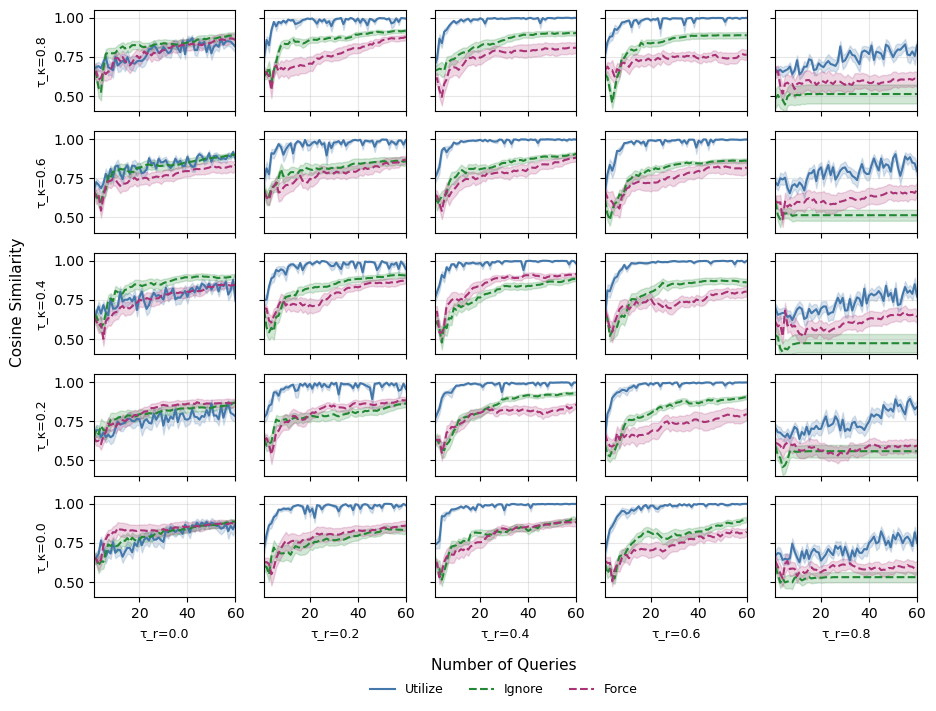

Plotting: ['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random']


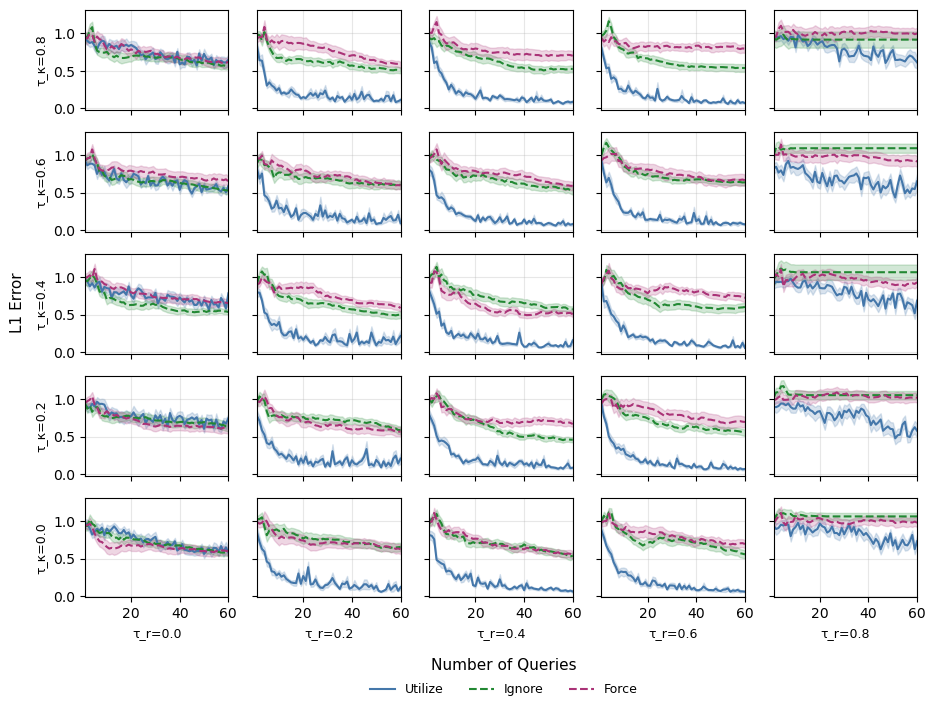

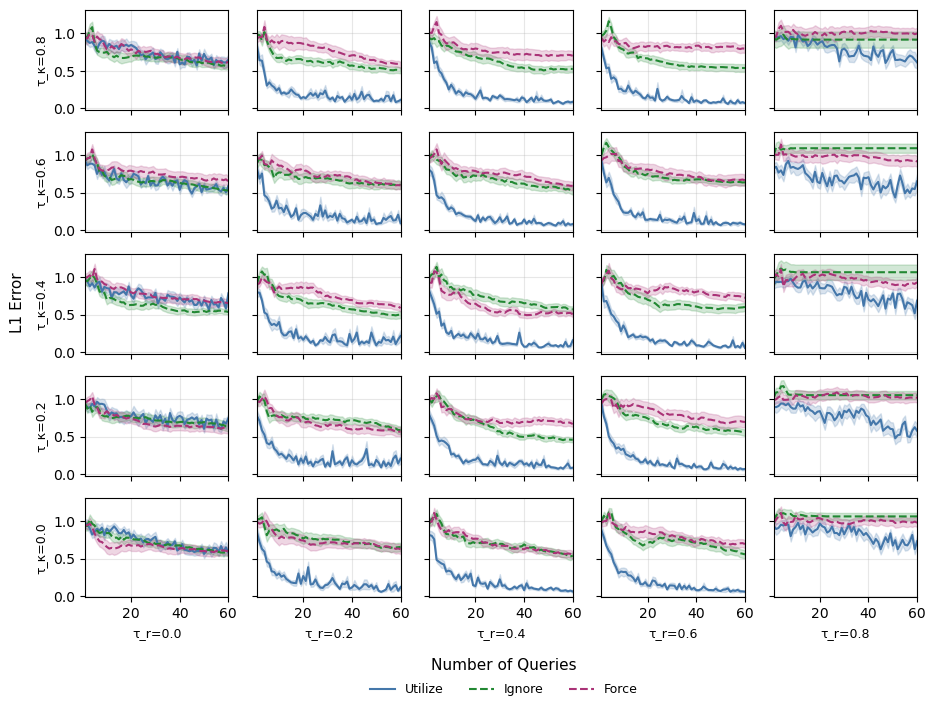

In [59]:
plot_methods_grid(
    results, taus, tau_primes, T,
    methods_to_plot=['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random'],
    metric='cos_sims',
    ylim=(0.4, 1.05),
)

plot_methods_grid(
    results, taus, tau_primes, T,
    methods_to_plot=['multiframe', 'bt_laplace_bald_k', 'bt_laplace_bald_random'],
    metric='l1',
)
